# **Titanic Survival Prediction: MLP & Hyperparameters Tuning with Optuna**

This notebook implements a complete machine learning pipeline to predict passenger survival on the Titanic dataset using a deep neural network built from scratch. It covers data preprocessing, handling missing values, feature encoding and scaling, and splitting the data into training and validation sets, with class imbalance addressed using SMOTE.

A multilayer perceptron (MLP) with ReLU hidden layers and a sigmoid output layer is trained using gradient descent and binary cross-entropy loss with L2 regularization. Hyperparameter tuning is performed using Optuna to identify the best network architecture and training settings. The final model is evaluated and used to generate predictions on the test set.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import pickle
import os
import json

# Dataset Loading & Quick Checks

## Titanic Dataset – Brief Field Description

- **PassengerId**: Unique identifier assigned to each passenger.  
- **Survived**: Target variable indicating survival status (0 = did not survive, 1 = survived).  
- **Pclass**: Passenger class (1 = First class, 2 = Second class, 3 = Third class).  
- **Name**: Passenger’s full name, including title.  
- **Sex**: Gender of the passenger.  
- **Age**: Age of the passenger in years.  
- **SibSp**: Number of siblings or spouses aboard the Titanic.  
- **Parch**: Number of parents or children aboard the Titanic.  
- **Ticket**: Ticket number.  
- **Fare**: Passenger fare paid for the ticket.  
- **Cabin**: Cabin number (if available).  
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).  

In [ ]:
train_data = '/content/drive/MyDrive/Datasets/train.csv'
test_data= '/content/drive/MyDrive/Datasets/test.csv'
full_data = '/content/drive/MyDrive/Datasets/titanic full.xls'

In [ ]:
train_df = pd.read_csv(train_data)
test_df  = pd.read_csv(test_data)
full_df  = pd.read_excel(full_data)
print("Train shape:",train_df.shape,". Test shape:", test_df.shape,"Full dataset's shape:",full_df.shape)

Train shape: (891, 12) . Test shape: (418, 11) Full dataset's shape: (1309, 14)


In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
full_df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Handling Missing Values

Before training the model, we address missing values to avoid errors and reduce bias.

In [ ]:
print("Missing values per column:")
print(train_df.isna().sum())

print("\nNumber of duplicate rows:")
print(train_df.duplicated().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Number of duplicate rows:
0


<Axes: >

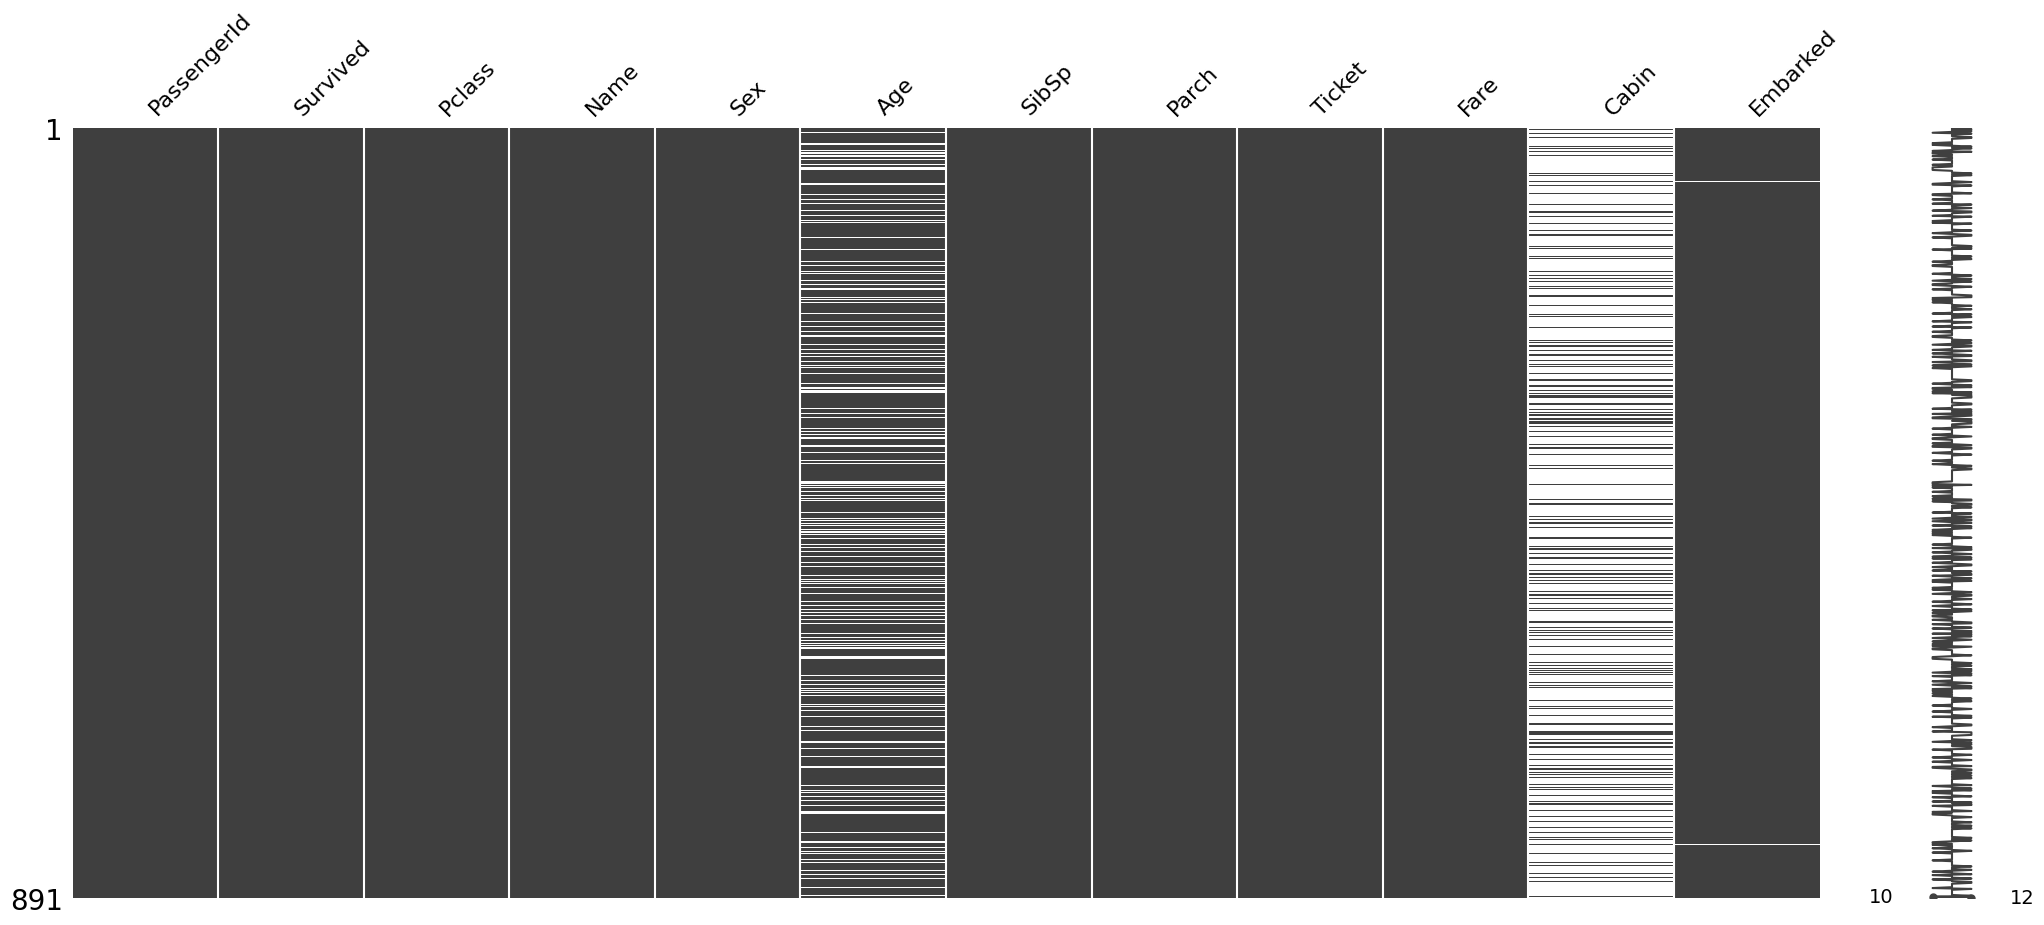

In [ ]:
msno.matrix(train_df)

### Missing Values Summary (Training Set)
- **Age (177 missing values)**: This is an important predictive feature (e.g., children had higher survival rates). Dropping these rows would remove a large portion of the data, so we **impute** missing ages.
  - We use **median imputation grouped by `Sex` and `Pclass`** to preserve differences between passenger groups.
- **Embarked (2 missing values)**: This feature has very few missing values, so we fill them using the **most frequent category (mode)**.
- **Cabin (687 missing values)**: The `Cabin` feature has a very high proportion of missing values, making it unreliable to use directly. We therefore **drop the Cabin column**


In [ ]:
train_df['Age'] = train_df.groupby(['Sex', 'Pclass'])['Age'] .transform(lambda x: x.fillna(x.median()))

train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

train_df.drop(columns=['Cabin'], inplace=True)


print("Missing values after cleaning (train):")
print(train_df.isna().sum())

Missing values after cleaning (train):
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipython-input-3025318480.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)


In [ ]:
print("Missing values per column:")
print(test_df.isna().sum())

print("\nNumber of duplicate rows:")
print(test_df.duplicated().sum())

Missing values per column:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Number of duplicate rows:
0


<Axes: >

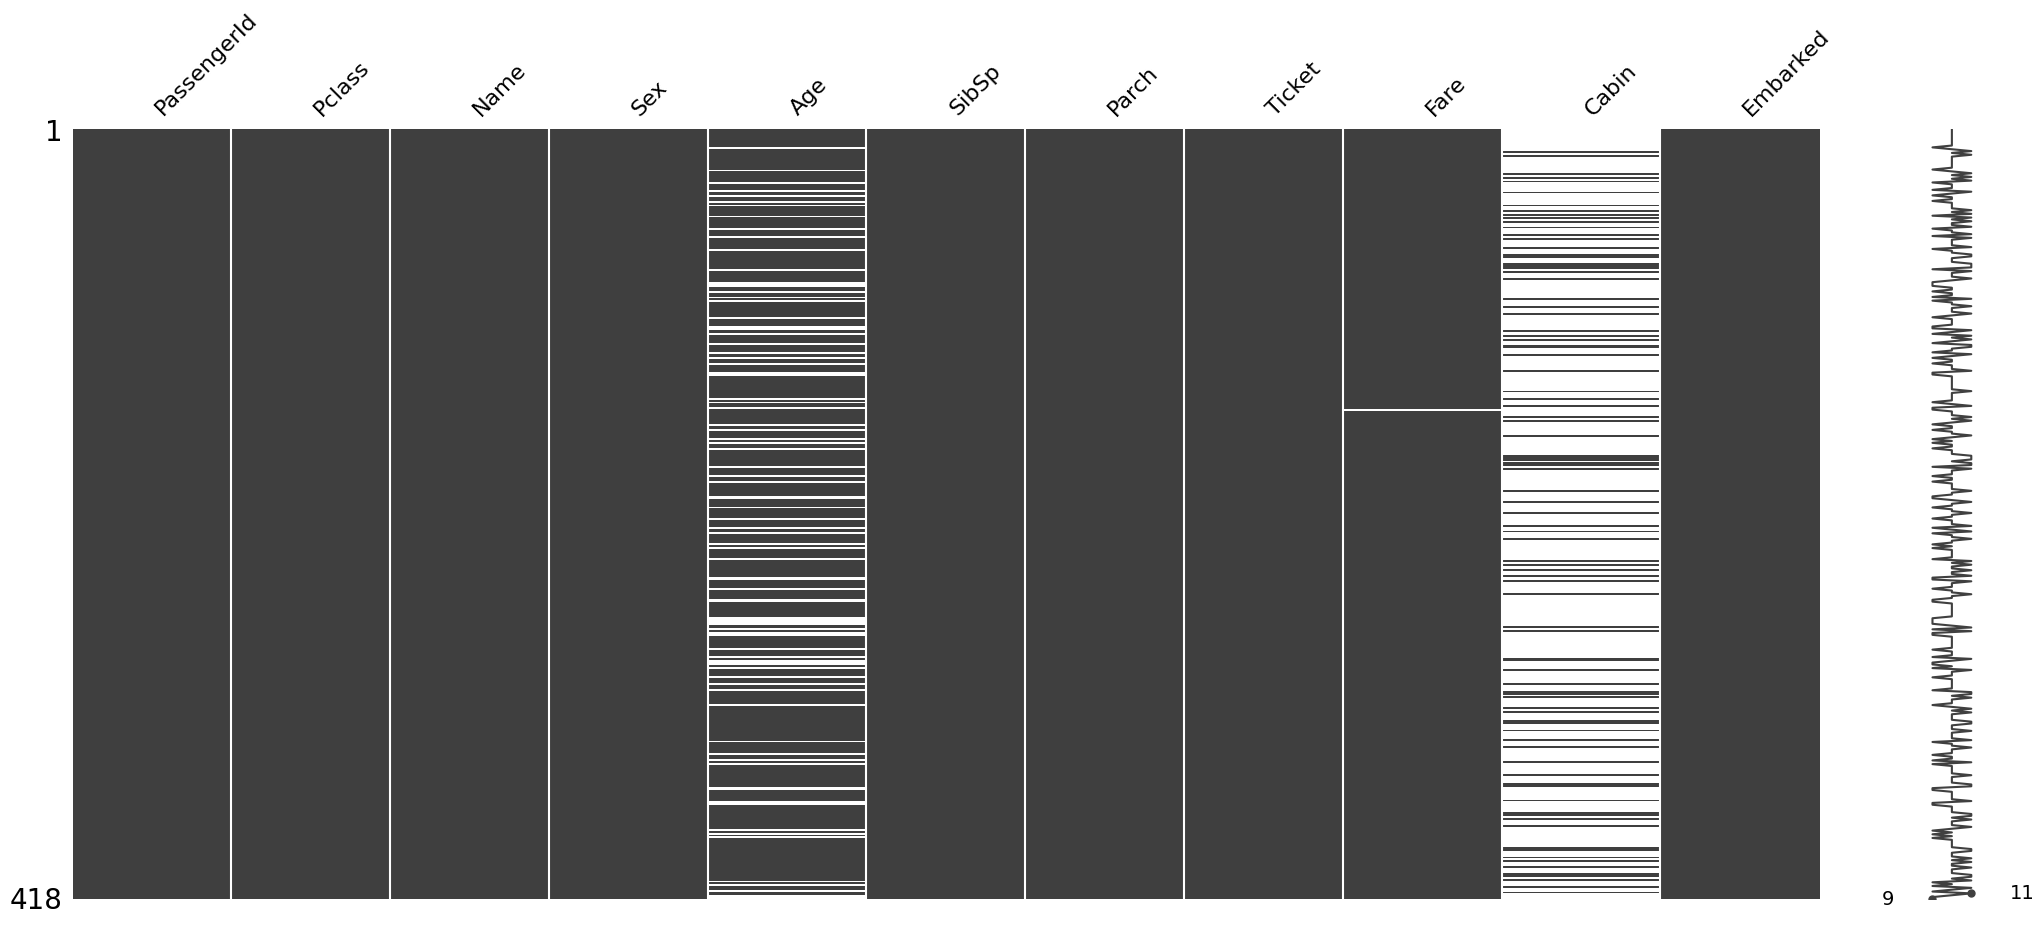

In [ ]:
msno.matrix(test_df)

## Missing Values Summary(Test Set)

- **Age (86 missing values)**  
  Age is a key predictive feature and was imputed using the median age grouped by passenger sex and class.

- **Fare (1 missing value)**  
  The missing fare value was imputed using the median fare to avoid introducing bias.

- **Cabin (327 missing values)**  
  Due to a high proportion of missing values, the Cabin feature was removed from the test dataset.

In [ ]:
test_df['Age'] = test_df.groupby(['Sex', 'Pclass'])['Age'] \
                        .transform(lambda x: x.fillna(x.median()))

test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

test_df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning (test):")
print(test_df.isna().sum())

Missing values after cleaning (test):
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipython-input-4111119061.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)


## Data Balance Check

In [ ]:
train_df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


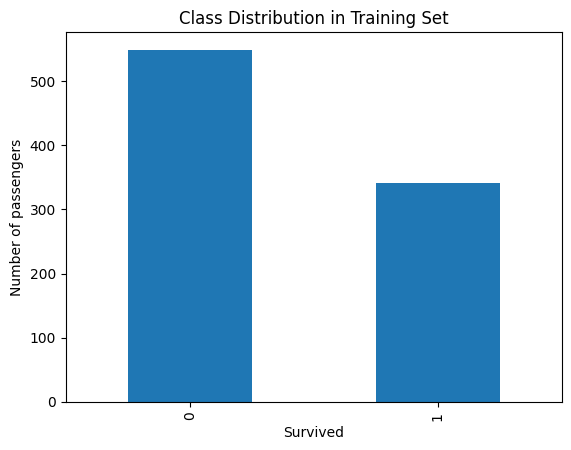

In [ ]:
import matplotlib.pyplot as plt

train_df['Survived'].value_counts().plot(kind='bar')
plt.xlabel('Survived')
plt.ylabel('Number of passengers')
plt.title('Class Distribution in Training Set')
plt.show()

## Feature Preparation

I am seperating the target variable `Survived`  from the input features.  
The columns `Name` and `Ticket` will be removed due to their high cardinality and limited predictive value.  
Categorical features (`Sex` and `Embarked`) will be encoded numerically using label encoding to make them suitable for model training.

In [ ]:
X = train_df.drop(columns=['Survived', 'Name', 'Ticket'])
y = train_df['Survived']

X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])

In [ ]:
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,1,22.0,1,0,7.2500,2
1,2,1,0,38.0,1,0,71.2833,0
2,3,3,0,26.0,0,0,7.9250,2
3,4,1,0,35.0,1,0,53.1000,2
4,5,3,1,35.0,0,0,8.0500,2


## Train–Validation Split and Class Balancing
I need first to split data into training and validation sets using a stratified split to preserve the original class distribution.  
SMOTE will be then applied **only to the training set** to handle class imbalance and avoid data leakage

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
Survived
1    439
0    439
Name: count, dtype: int64


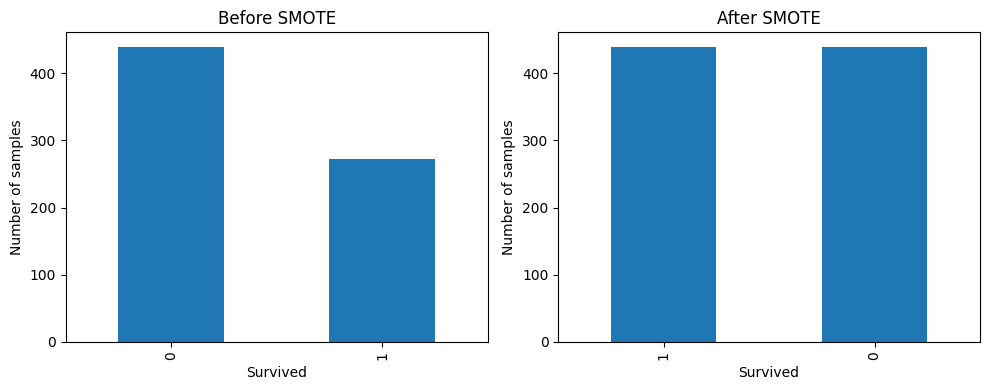

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Number of samples')

# After SMOTE
y_train_smote.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Number of samples')

plt.tight_layout()
plt.show()

## Feature Scaling Method

Feature Scaling is the process of creating, transforming or selecting the most relevant variables (features) from raw data to improve model performance.

It helps ensure that all features contribute more equally during model training, especially when dealing with gradient-based or distance-based algorithms.

I chose to work with `StandardScaler` to normalize numerical features by removing the mean and scaling to unit variance.  
This choice is well suited for distance-based algorithms and SMOTE, and is less sensitive to outliers than MinMax scaling.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)

In [ ]:
# Column names stay the same
feature_names = X_train.columns

# Convert SMOTE-scaled training set
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_names
)

# Convert validation set (NO SMOTE here, index is still valid)
X_val_scaled_df = pd.DataFrame(
    X_val_scaled,
    columns=feature_names,
    index=X_val.index
)

# Check
X_train_scaled_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.969447,0.931498,0.902247,-0.316982,-0.441476,-0.455660,0.490216,0.669528
1,0.145872,-0.241895,0.902247,0.070678,-0.441476,-0.455660,-0.701809,0.669528
2,0.325419,-1.415289,0.902247,0.845998,-0.441476,-0.455660,3.977590,0.669528
3,1.605668,0.931498,-1.108344,-0.859707,-0.441476,0.822517,-0.504530,0.669528
4,1.394896,-0.241895,-1.108344,0.148210,0.581258,0.822517,-0.147951,0.669528


# Activation Functions

In [ ]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# Parameters Initialization

In [ ]:
def initialize_param(layer_dims):
    """
    Initialize parameters for an L-layer MLP using He initialization.

    layer_dims: list like [n_x, n_h1, ..., n_hL, 1]
    Returns:
      parameters dict with W1,b1,...,WL,bL
    """
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims) - 1  # number of layers (excluding input)

    for l in range(1, L + 1):
        parameters[f"W{l}"] = np.random.randn(
            layer_dims[l], layer_dims[l - 1]
        ) * np.sqrt(2.0 / layer_dims[l - 1])   # He init (for ReLU)

        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))

    return parameters

# Forward Pass

In [ ]:
def forward_pass(X, parameters):
    """
    General L-layer MLP forward pass.
    Hidden layers: ReLU
    Output layer: Sigmoid

    X: (n_x, m)
    parameters: W1,b1,...,WL,bL
    Returns:
      AL: (1, m)
      caches: list of caches [(A0,W1,b1,Z1), ..., (A_{L-1},WL,bL,ZL)]
    """
    caches = []
    A = X
    L = len(parameters) // 2  # number of layers

    # Hidden layers 1..L-1
    for l in range(1, L):
        A_prev = A
        W = parameters[f'W{l}']
        b = parameters[f'b{l}']
        Z = np.dot(W, A_prev) + b
        A = relu(Z)
        caches.append((A_prev, W, b, Z))

    # Output layer L
    A_prev = A
    WL = parameters[f'W{L}']
    bL = parameters[f'b{L}']
    ZL = np.dot(WL, A_prev) + bL
    AL = sigmoid(ZL)
    caches.append((A_prev, WL, bL, ZL))

    return AL, caches

# Cost

In [ ]:
def compute_cost(AL, Y, parameters, lambd=0.0, eps=1e-15):
    """
    Cost for L-layer MLP (binary classification).

    AL: (1, m) predicted probabilities
    Y:  (1, m) true labels {0,1}
    parameters: dict containing W1,b1,...,WL,bL
    lambd: L2 regularization strength
    """
    m = Y.shape[1]

    AL = np.clip(AL, eps, 1 - eps) #for numerical stability

    # Binary cross-entropy loss
    cross_entropy_cost = -(1/m) * np.sum(
        Y * np.log(AL) + (1 - Y) * np.log(1 - AL)
    )

    # L2 regularization (ONLY weights, not biases)
    L2_cost = 0.0
    if lambd > 0:
        L = len(parameters) // 2
        for l in range(1, L + 1):
            L2_cost += np.sum(np.square(parameters[f"W{l}"]))
        L2_cost *= (lambd / (2 * m))

    cost = cross_entropy_cost + L2_cost
    return float(np.squeeze(cost))

# Backward Propagation

In [ ]:
def backward_pass(AL, Y, caches, lambd=0.0):
    """
    General L-layer MLP backprop (ReLU hidden, sigmoid output).
    caches: list from forward_pass
    Returns grads dict: dW1,db1,...,dWL,dbL
    """
    grads = {}
    L = len(caches)
    m = Y.shape[1]

    # ---- Output layer ----
    A_prev, W, b, Z = caches[-1]
    dZ = AL - Y                                  # (1, m)
    dW = (1/m) * np.dot(dZ, A_prev.T) + (lambd/m) * W
    db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    grads[f"dW{L}"] = dW
    grads[f"db{L}"] = db

    # ---- Hidden layers: L-1 .. 1 ----
    for l in reversed(range(L-1)):               # indices: L-2 .. 0
        A_prev, W, b, Z = caches[l]
        dZ = dA_prev * relu_derivative(Z)
        dW = (1/m) * np.dot(dZ, A_prev.T) + (lambd/m) * W
        db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = np.dot(W.T, dZ)

        grads[f"dW{l+1}"] = dW
        grads[f"db{l+1}"] = db

    return grads

# Parameters Update

In [ ]:
def update_parameters(parameters, grads, learning_rate):
    """
    Gradient descent update for an L-layer MLP.

    parameters: dict containing W1,b1,...,WL,bL
    grads: dict containing dW1,db1,...,dWL,dbL
    learning_rate: step size
    """
    L = len(parameters) // 2

    for l in range(1, L + 1):
        parameters[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * grads[f"db{l}"]

    return parameters

# Evaluation Metrics

In [ ]:
def compute_metrics(AL, Y, threshold=0.5):
    """
    Compute accuracy, precision, recall, F1 for binary classification.

    AL: predicted probabilities (1, m) or (m,) or (m,1)
    Y:  true labels           (1, m) or (m,) or (m,1)
    threshold: cutoff to convert probs to 0/1
    """
    AL = np.array(AL)
    Y  = np.array(Y)

    # Flatten to 1D (length m) for easier boolean logic
    AL = AL.reshape(-1)
    Y  = Y.reshape(-1)

    # Convert probabilities to predicted labels
    preds = (AL >= threshold).astype(int)

    TP = np.sum((preds == 1) & (Y == 1))
    TN = np.sum((preds == 0) & (Y == 0))
    FP = np.sum((preds == 1) & (Y == 0))
    FN = np.sum((preds == 0) & (Y == 1))

    accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-12)
    precision = TP / (TP + FP + 1e-12)
    recall    = TP / (TP + FN + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "TP": int(TP), "TN": int(TN), "FP": int(FP), "FN": int(FN)
    }

# Checkpoints after 50 epochs

In [ ]:
def save_checkpoint(parameters, epoch, train_cost, val_cost, path="checkpoints"):
    """
    Save model parameters and training state for an L-layer MLP.

    parameters: dict W1,b1,...,WL,bL (numpy arrays)
    epoch: current epoch
    train_cost: training loss at this epoch
    val_cost: validation loss at this epoch
    """
    if not os.path.exists(path):
        os.makedirs(path)

    checkpoint = {
        "epoch": epoch,
        "parameters": {k: v.tolist() for k, v in parameters.items()},
        "train_cost": float(train_cost),
        "val_cost": float(val_cost)
    }

    filename = os.path.join(path, f"checkpoint_epoch_{epoch}.json")
    with open(filename, "w") as f:
        json.dump(checkpoint, f, indent=4)


# Prediction

In [ ]:
def predict(X, parameters, threshold=0.5):
    """
    Generate binary predictions from an L-layer MLP.

    X: (n_features, m)
    parameters: trained model parameters
    threshold: probability cutoff
    Returns:
      predictions: (1, m)
    """
    AL, _ = forward_pass(X, parameters)
    predictions = (AL >= threshold).astype(int)
    return predictions

## MLP training function

In [ ]:
def model(
    X_train, y_train,
    X_val, y_val,
    layer_dims,
    learning_rate=0.01,
    num_epochs=1000,
    lambd=0.01,
    checkpoint_file="model_checkpoint.pkl",
    print_every=50
):
    """
    Train an L-layer MLP (ReLU hidden layers + sigmoid output) from scratch.

    Expected shapes:
      X_train: (n_x, m_train)
      y_train: (1, m_train)
      X_val:   (n_x, m_val)
      y_val:   (1, m_val)
    """

    # --- Convert y to numpy with shape (1, m) ---
    if isinstance(y_train, (pd.Series, pd.DataFrame)):
        y_train = y_train.to_numpy()
    if isinstance(y_val, (pd.Series, pd.DataFrame)):
        y_val = y_val.to_numpy()

    y_train = np.array(y_train)
    y_val = np.array(y_val)

    if y_train.ndim == 1:
        y_train = y_train.reshape(1, -1)
    if y_val.ndim == 1:
        y_val = y_val.reshape(1, -1)

    # --- Initialize parameters ---
    parameters = initialize_param(layer_dims)  # must create W1..WL, b1..bL

    train_costs, val_costs = [], []
    best_val_cost = float("inf")
    best_checkpoint = None

    for epoch in range(1, num_epochs + 1):
        # ---- Forward ----
        AL_train, caches_train = forward_pass(X_train, parameters)
        AL_val, _ = forward_pass(X_val, parameters)

        # ---- Cost ----
        train_cost = compute_cost(AL_train, y_train, parameters, lambd)
        val_cost = compute_cost(AL_val, y_val, parameters, lambd)

        train_costs.append(train_cost)
        val_costs.append(val_cost)

        # ---- Backward (use training caches) ----
        grads = backward_pass(AL_train, y_train, caches_train, lambd)

        # ---- Update ----
        parameters = update_parameters(parameters, grads, learning_rate)

        # ---- Logging + checkpoint ----
        if epoch % print_every == 0 or epoch == 1:
            # metrics using probabilities (safer) or predictions
            train_metrics = compute_metrics(AL_train, y_train)  # threshold inside
            val_metrics   = compute_metrics(AL_val, y_val)

            print(f"Epoch {epoch:04d} | Train cost={train_cost:.4f} | Val cost={val_cost:.4f}")
            print(f"  Train: acc={train_metrics['accuracy']:.4f} prec={train_metrics['precision']:.4f} rec={train_metrics['recall']:.4f} f1={train_metrics['f1']:.4f}")
            print(f"  Val:   acc={val_metrics['accuracy']:.4f} prec={val_metrics['precision']:.4f} rec={val_metrics['recall']:.4f} f1={val_metrics['f1']:.4f}")

        # Save best checkpoint (recommended)
        if val_cost < best_val_cost:
            best_val_cost = val_cost
            best_checkpoint = {
                "epoch": epoch,
                "parameters": parameters,
                "train_cost": train_cost,
                "val_cost": val_cost,
                "layer_dims": layer_dims,
                "learning_rate": learning_rate,
                "lambd": lambd
            }
            with open(checkpoint_file, "wb") as f:
                pickle.dump(best_checkpoint, f)

    # ---- Plot costs ----
    plt.figure(figsize=(10, 5))
    plt.plot(train_costs, label="Training Cost")
    plt.plot(val_costs, label="Validation Cost")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.title("Training vs Validation Cost")
    plt.legend()
    plt.show()

    # Load best parameters back (so returned model is the best on validation)
    if best_checkpoint is not None:
        parameters = best_checkpoint["parameters"]
        print(f"Best checkpoint saved at epoch {best_checkpoint['epoch']} with val_cost={best_checkpoint['val_cost']:.4f}")

    return parameters, train_costs, val_costs

In [ ]:
print("X_train_scaled_df shape:", X_train_scaled_df.shape)
print("X_val_scaled_df shape:", X_val_scaled_df.shape)

print("y_train_smote shape:", y_train_smote.shape)
print("y_val shape:", y_val.shape)

X_train_scaled_df shape: (878, 8)
X_val_scaled_df shape: (179, 8)
y_train_smote shape: (878,)
y_val shape: (179,)


In [ ]:
# Convert X to (n_features, m)
X_train_mlp = X_train_scaled_df.to_numpy().T   # (8, 878)
X_val_mlp   = X_val_scaled_df.to_numpy().T     # (8, 179)

# Convert y to (1, m)
y_train_mlp = y_train_smote.to_numpy().reshape(1, -1)  # (1, 878)
y_val_mlp   = y_val.to_numpy().reshape(1, -1)          # (1, 179)

print("X_train_mlp:", X_train_mlp.shape)
print("y_train_mlp:", y_train_mlp.shape)
print("X_val_mlp:", X_val_mlp.shape)
print("y_val_mlp:", y_val_mlp.shape)

assert X_train_mlp.shape[1] == y_train_mlp.shape[1]
assert X_val_mlp.shape[1] == y_val_mlp.shape[1]

X_train_mlp: (8, 878)
y_train_mlp: (1, 878)
X_val_mlp: (8, 179)
y_val_mlp: (1, 179)


The neural network architecture is defined by `layer_dims = [8, 16, 8, 1]`, where 8 corresponds to the number of input features, 16 and 8 represent the number of neurons in the first and second hidden layers respectively, and 1 denotes the single output neuron used for binary classification. This architecture allows the model to learn non-linear relationships while remaining simple enough to reduce overfitting.


In [ ]:
layer_dims = [8, 16, 8, 1]

Epoch 0001 | Train cost=0.6594 | Val cost=0.6158
  Train: acc=0.6025 prec=0.7228 rec=0.3326 f1=0.4555
  Val:   acc=0.6816 prec=0.6429 rec=0.3913 f1=0.4865
Epoch 0100 | Train cost=0.5343 | Val cost=0.5431
  Train: acc=0.7768 prec=0.7956 rec=0.7449 f1=0.7694
  Val:   acc=0.7430 prec=0.6494 rec=0.7246 f1=0.6849
Epoch 0200 | Train cost=0.4971 | Val cost=0.5255
  Train: acc=0.8075 prec=0.8154 rec=0.7950 f1=0.8051
  Val:   acc=0.7709 prec=0.6892 rec=0.7391 f1=0.7133
Epoch 0300 | Train cost=0.4770 | Val cost=0.5144
  Train: acc=0.8144 prec=0.8270 rec=0.7950 f1=0.8107
  Val:   acc=0.7821 prec=0.7083 rec=0.7391 f1=0.7234
Epoch 0400 | Train cost=0.4630 | Val cost=0.5063
  Train: acc=0.8212 prec=0.8341 rec=0.8018 f1=0.8177
  Val:   acc=0.7877 prec=0.7123 rec=0.7536 f1=0.7324
Epoch 0500 | Train cost=0.4519 | Val cost=0.4999
  Train: acc=0.8257 prec=0.8357 rec=0.8109 f1=0.8231
  Val:   acc=0.7989 prec=0.7324 rec=0.7536 f1=0.7429
Epoch 0600 | Train cost=0.4422 | Val cost=0.4941
  Train: acc=0.8326 p

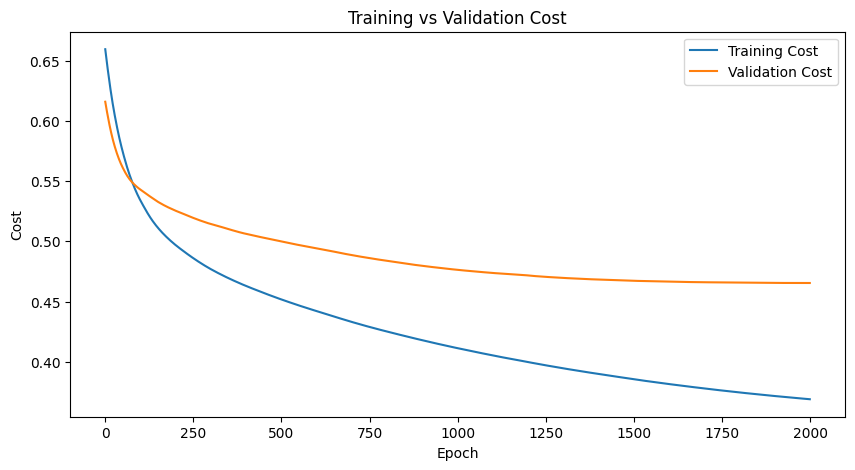

Best checkpoint saved at epoch 2000 with val_cost=0.4654


In [ ]:
parameters, train_costs, val_costs = model(
    X_train_mlp, y_train_mlp,
    X_val_mlp, y_val_mlp,
    layer_dims=layer_dims,
    learning_rate=0.01,
    num_epochs=2000,
    lambd=0.01,
    checkpoint_file="mlp_titanic.pkl",
    print_every=100
)

Epoch 0001 | Train cost=0.6594 | Val cost=0.6158
  Train: acc=0.6025 prec=0.7228 rec=0.3326 f1=0.4555
  Val:   acc=0.6816 prec=0.6429 rec=0.3913 f1=0.4865
Epoch 0100 | Train cost=0.4523 | Val cost=0.5002
  Train: acc=0.8257 prec=0.8357 rec=0.8109 f1=0.8231
  Val:   acc=0.7933 prec=0.7222 rec=0.7536 f1=0.7376
Epoch 0200 | Train cost=0.4118 | Val cost=0.4762
  Train: acc=0.8349 prec=0.8451 rec=0.8200 f1=0.8324
  Val:   acc=0.7989 prec=0.7391 rec=0.7391 f1=0.7391
Epoch 0300 | Train cost=0.3860 | Val cost=0.4671
  Train: acc=0.8405 prec=0.8568 rec=0.8178 f1=0.8368
  Val:   acc=0.7933 prec=0.7353 rec=0.7246 f1=0.7299
Epoch 0400 | Train cost=0.3692 | Val cost=0.4655
  Train: acc=0.8417 prec=0.8659 rec=0.8087 f1=0.8363
  Val:   acc=0.7709 prec=0.7121 rec=0.6812 f1=0.6963


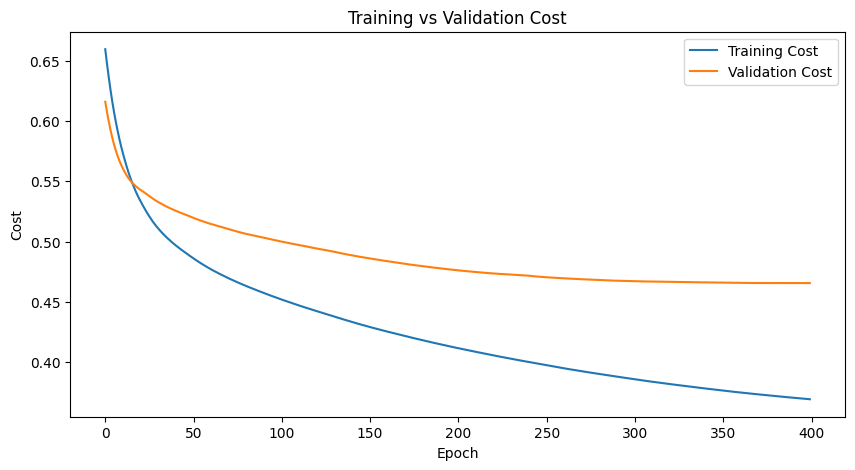

Best checkpoint saved at epoch 398 with val_cost=0.4655


In [ ]:
parameters, train_costs, val_costs = model(
    X_train_mlp, y_train_mlp,
    X_val_mlp, y_val_mlp,
    layer_dims=layer_dims,
    learning_rate=0.05,
    num_epochs=400,      # stop earlier
    lambd=0.01,
    checkpoint_file="mlp_titanic.pkl",
    print_every=100
)

In [ ]:
# Get probabilities (preferred)
AL_train, _ = forward_pass(X_train_mlp, parameters)
AL_val, _   = forward_pass(X_val_mlp, parameters)

# Compute metrics directly from probabilities
train_metrics = compute_metrics(AL_train, y_train_mlp)
val_metrics   = compute_metrics(AL_val, y_val_mlp)

print("\nFinal Metrics:")
print(f"Train Metrics: {train_metrics}")
print(f"Validation Metrics: {val_metrics}")


Final Metrics:
Train Metrics: {'accuracy': 0.8416856492027325, 'precision': 0.8658536585365832, 'recall': 0.8086560364464673, 'f1': 0.8362779740866599, 'TP': 355, 'TN': 384, 'FP': 55, 'FN': 84}
Validation Metrics: {'accuracy': 0.7709497206703868, 'precision': 0.7121212121212014, 'recall': 0.6811594202898452, 'f1': 0.6962962962957863, 'TP': 47, 'TN': 91, 'FP': 19, 'FN': 22}


# Hyperparameter Tuning

Hyperparameter tuning is a crucial step in machine learning that aims to improve model performance by finding optimal parameter settings. **Optuna** is an open-source library for automated hyperparameter optimization that efficiently explores the search space using advanced strategies such as the **Tree-structured Parzen Estimator (TPE)**. It is flexible, easy to integrate, and compatible with a wide range of machine learning frameworks.


# Optuna Installation

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 4.5 MB/s eta 0:00:00


# Objective Function

The objective function defines both the model and the hyperparameters to be optimized. In the following objective function, different search ranges are specified for the number of hidden layers, the number of units per layer, the learning rate, and the regularization parameter (lambda). This allows Optuna to systematically explore various network configurations and training settings to identify the combination that yields the best performance.

In [ ]:
import optuna

def objective(trial):
    # Number of hidden layers
    n_layers = trial.suggest_int("n_layers", 1, 5)

    # Units per hidden layer
    hidden_units = [trial.suggest_int(f"n_units_{i}", 8, 64) for i in range(n_layers)]

    # Architecture: input -> hidden(s) -> output
    layer_dims = [X_train_mlp.shape[0]] + hidden_units + [1]

    # Hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    lambd = trial.suggest_float("lambda_reg", 1e-5, 1e-1, log=True)

    # Keep epochs moderate for tuning speed
    num_epochs = 1500

    # Train model (model() initializes internally)
    params, train_costs, val_costs = model(
        X_train_mlp, y_train_mlp,
        X_val_mlp, y_val_mlp,
        layer_dims=layer_dims,
        learning_rate=learning_rate,
        num_epochs=num_epochs,
        lambd=lambd,
        checkpoint_file=f"optuna_trial_{trial.number}.pkl",
        print_every=999999  # effectively silent
    )

    # Evaluate on validation using probabilities
    AL_val, _ = forward_pass(X_val_mlp, params)
    val_metrics = compute_metrics(AL_val, y_val_mlp)

    return val_metrics["accuracy"]

# Run the Study

To perform hyperparameter optimization, a study is created and the objective function is optimized using Optuna. During this process, Optuna runs multiple trials, where each trial evaluates a different combination of hyperparameters with the goal of maximizing the objective function.

In this step, 50 trials are executed. Since no sampler is explicitly specified, Optuna uses its default Tree-structured Parzen Estimator (TPE) sampler. By default, TPE begins with an initial phase of random sampling to explore the search space before switching to a more informed, Bayesian-guided search strategy.

After the initial random sampling phase, TPE leverages the results of previous trials to guide the search toward more promising hyperparameter configurations. Once all trials are completed, the best-performing hyperparameters—those that achieve the highest validation accuracy—are selected. These optimal parameters are then used to train and refine the final deep neural network (DNN) model.


[I 2026-02-10 02:10:54,861] A new study created in memory with name: no-name-6112d885-c693-495a-9770-5856af32263f


Epoch 0001 | Train cost=0.7678 | Val cost=0.7953
  Train: acc=0.6150 prec=0.6247 rec=0.5763 f1=0.5995
  Val:   acc=0.6089 prec=0.4941 rec=0.6087 f1=0.5455


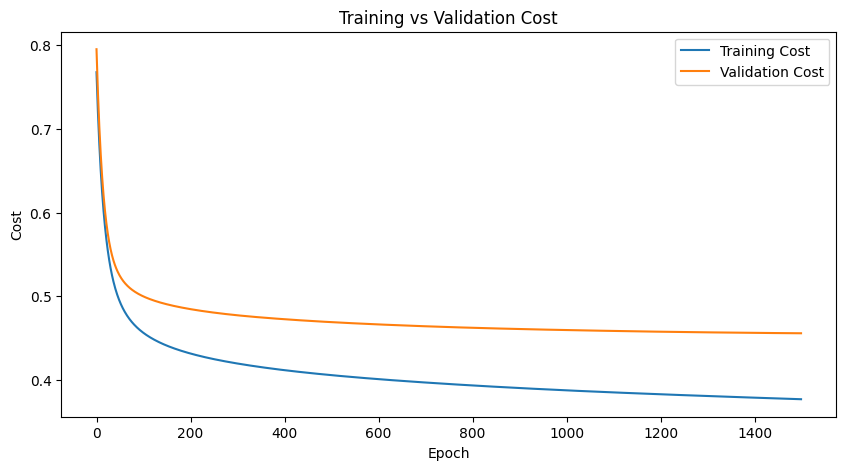

[I 2026-02-10 02:10:59,274] Trial 0 finished with value: 0.7932960893854705 and parameters: {'n_layers': 1, 'n_units_0': 56, 'learning_rate': 0.01922867938692751, 'lambda_reg': 0.0015578046543808634}. Best is trial 0 with value: 0.7932960893854705.


Best checkpoint saved at epoch 1500 with val_cost=0.4556
Epoch 0001 | Train cost=0.7476 | Val cost=0.6947
  Train: acc=0.4749 prec=0.4329 rec=0.1617 f1=0.2355
  Val:   acc=0.5642 prec=0.3200 rec=0.1159 f1=0.1702


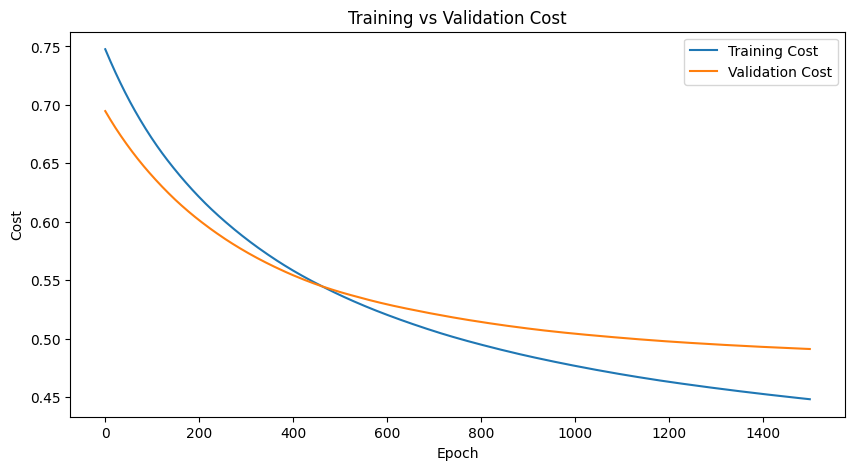

[I 2026-02-10 02:11:09,985] Trial 1 finished with value: 0.7653631284916158 and parameters: {'n_layers': 4, 'n_units_0': 64, 'n_units_1': 50, 'n_units_2': 53, 'n_units_3': 27, 'learning_rate': 0.0007152451892629072, 'lambda_reg': 0.00047819902148759855}. Best is trial 0 with value: 0.7932960893854705.


Best checkpoint saved at epoch 1500 with val_cost=0.4912
Epoch 0001 | Train cost=0.8708 | Val cost=0.7616
  Train: acc=0.3907 prec=0.2108 rec=0.0797 f1=0.1157
  Val:   acc=0.5140 prec=0.2353 rec=0.1159 f1=0.1553


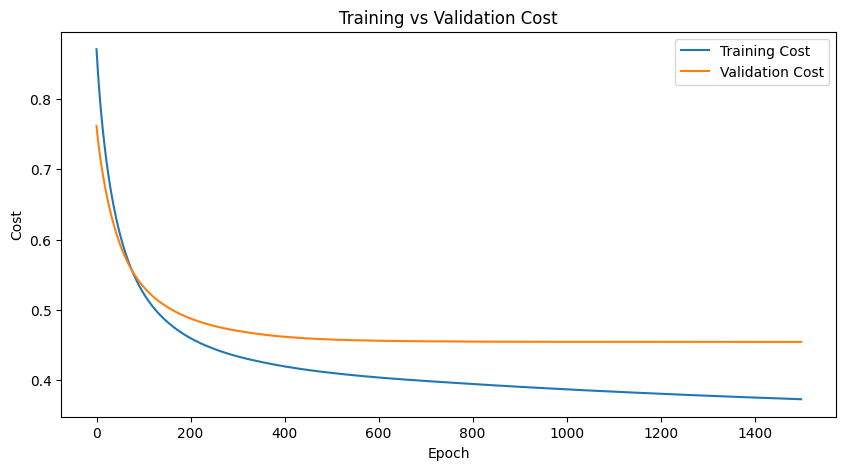

[I 2026-02-10 02:11:17,615] Trial 2 finished with value: 0.8100558659217832 and parameters: {'n_layers': 3, 'n_units_0': 27, 'n_units_1': 29, 'n_units_2': 16, 'learning_rate': 0.008072897217576923, 'lambda_reg': 0.027617985412086335}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4546
Epoch 0001 | Train cost=0.7825 | Val cost=0.9341
  Train: acc=0.5490 prec=0.5270 rec=0.9544 f1=0.6791
  Val:   acc=0.4246 prec=0.3937 rec=0.9130 f1=0.5502


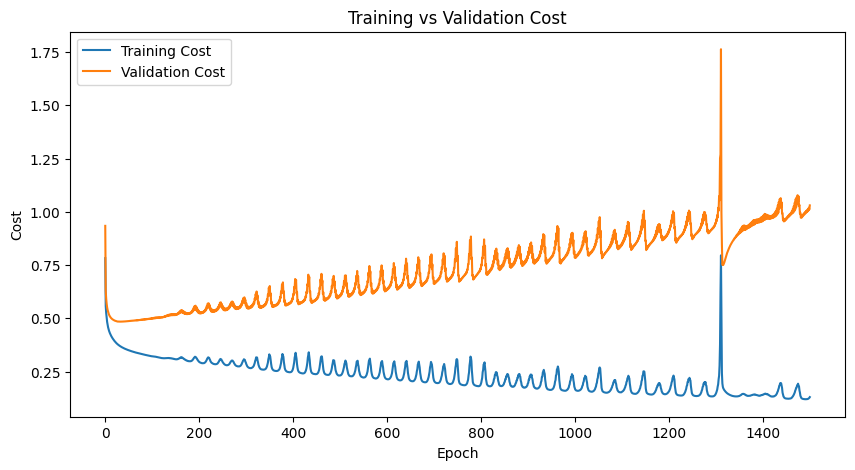

[I 2026-02-10 02:11:25,800] Trial 3 finished with value: 0.754189944134074 and parameters: {'n_layers': 5, 'n_units_0': 36, 'n_units_1': 49, 'n_units_2': 54, 'n_units_3': 15, 'n_units_4': 36, 'learning_rate': 0.08794408430965663, 'lambda_reg': 0.00015161869918885792}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 31 with val_cost=0.4845
Epoch 0001 | Train cost=0.8894 | Val cost=1.0298
  Train: acc=0.4852 prec=0.4895 rec=0.6879 f1=0.5720
  Val:   acc=0.4190 prec=0.3622 rec=0.6667 f1=0.4694


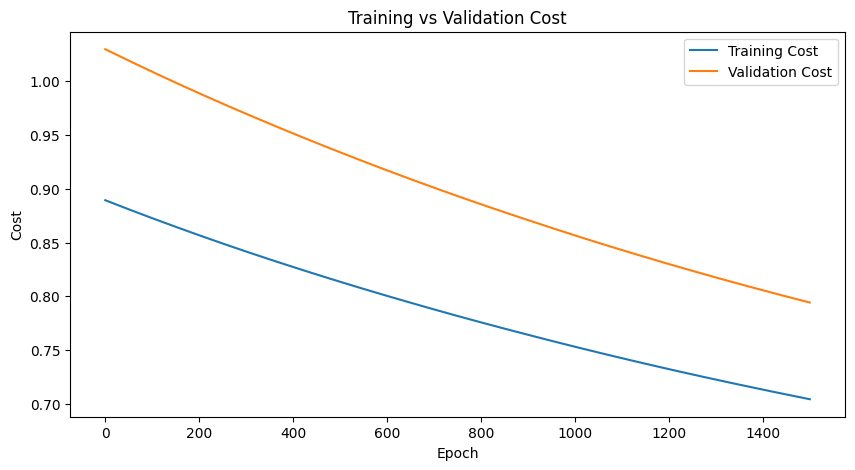

[I 2026-02-10 02:11:27,292] Trial 4 finished with value: 0.6703910614525103 and parameters: {'n_layers': 1, 'n_units_0': 13, 'learning_rate': 0.0006245840110472715, 'lambda_reg': 4.306987184550695e-05}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.7942
Epoch 0001 | Train cost=0.8093 | Val cost=1.0177
  Train: acc=0.5979 prec=0.5657 rec=0.8428 f1=0.6770
  Val:   acc=0.5084 prec=0.4240 rec=0.7681 f1=0.5464


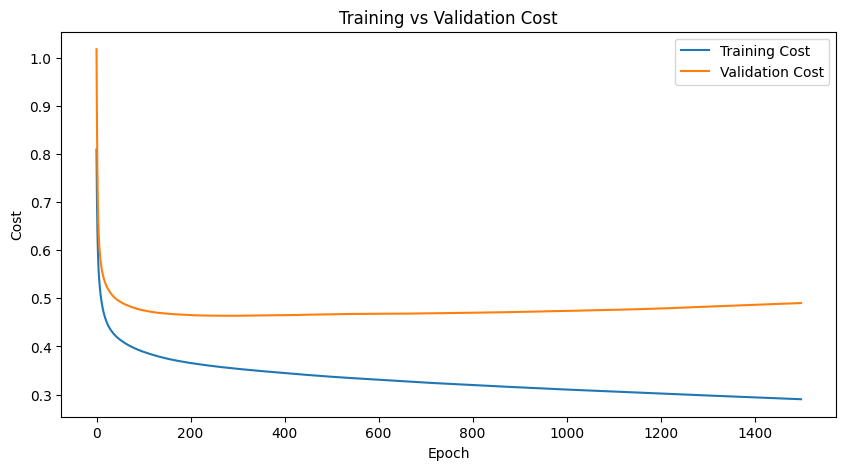

[I 2026-02-10 02:11:34,048] Trial 5 finished with value: 0.7821229050279286 and parameters: {'n_layers': 2, 'n_units_0': 44, 'n_units_1': 18, 'learning_rate': 0.0477147209335038, 'lambda_reg': 0.008830405354271443}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 270 with val_cost=0.4637
Epoch 0001 | Train cost=0.7967 | Val cost=0.8913
  Train: acc=0.5080 prec=0.5041 rec=0.9863 f1=0.6672
  Val:   acc=0.3911 prec=0.3864 rec=0.9855 f1=0.5551


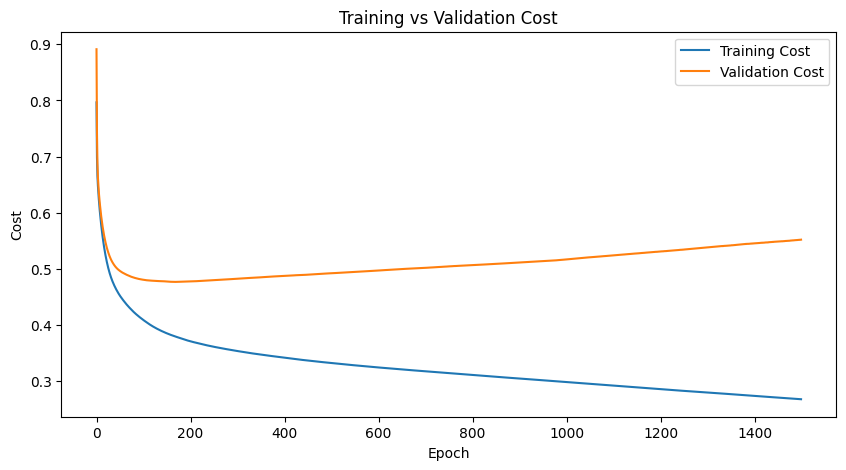

[I 2026-02-10 02:11:41,858] Trial 6 finished with value: 0.7765363128491577 and parameters: {'n_layers': 4, 'n_units_0': 49, 'n_units_1': 14, 'n_units_2': 58, 'n_units_3': 57, 'learning_rate': 0.025724889744035993, 'lambda_reg': 0.0009446091868241203}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 167 with val_cost=0.4768
Epoch 0001 | Train cost=0.7316 | Val cost=0.8396
  Train: acc=0.6856 prec=0.6667 rec=0.7426 f1=0.7026
  Val:   acc=0.6592 prec=0.5417 rec=0.7536 f1=0.6303


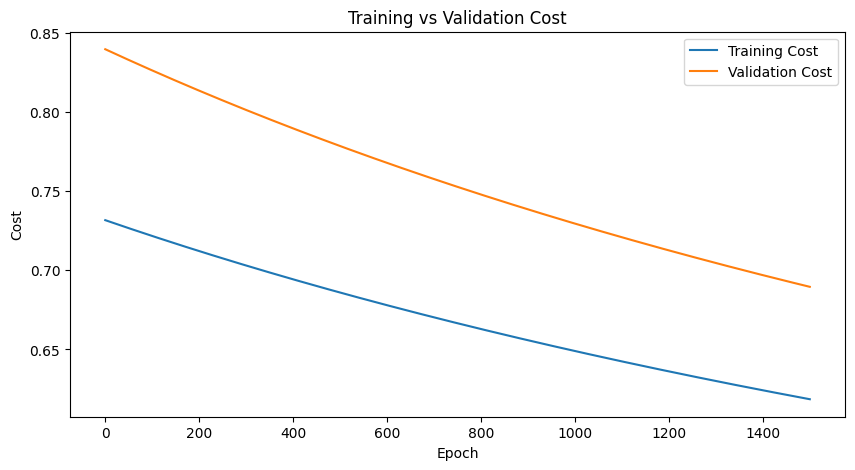

[I 2026-02-10 02:11:43,931] Trial 7 finished with value: 0.7039106145251357 and parameters: {'n_layers': 1, 'n_units_0': 29, 'learning_rate': 0.00024960959673432377, 'lambda_reg': 0.0004495359298595895}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.6895
Epoch 0001 | Train cost=0.9172 | Val cost=0.8945
  Train: acc=0.3405 prec=0.3387 rec=0.3349 f1=0.3368
  Val:   acc=0.3911 prec=0.2872 rec=0.3913 f1=0.3313


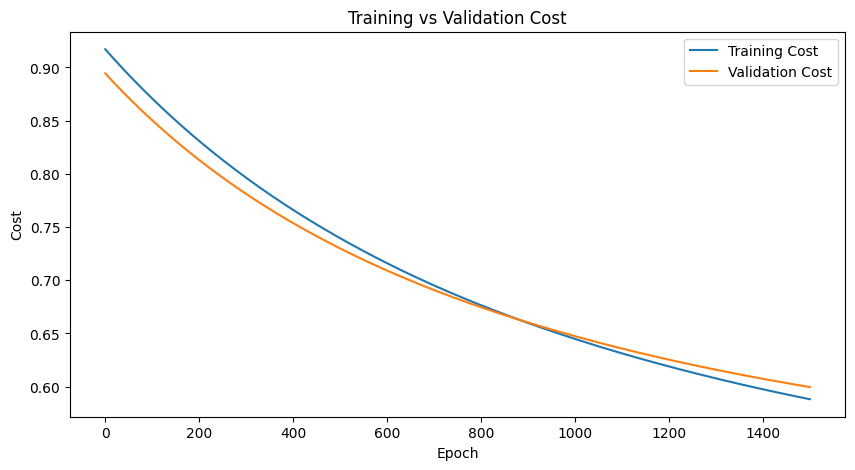

[I 2026-02-10 02:11:49,106] Trial 8 finished with value: 0.6983240223463648 and parameters: {'n_layers': 2, 'n_units_0': 45, 'n_units_1': 18, 'learning_rate': 0.00044826094397938833, 'lambda_reg': 0.0001070595163450748}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5996
Epoch 0001 | Train cost=0.7290 | Val cost=0.7209
  Train: acc=0.5763 prec=0.6218 rec=0.3895 f1=0.4790
  Val:   acc=0.5866 prec=0.4468 rec=0.3043 f1=0.3621


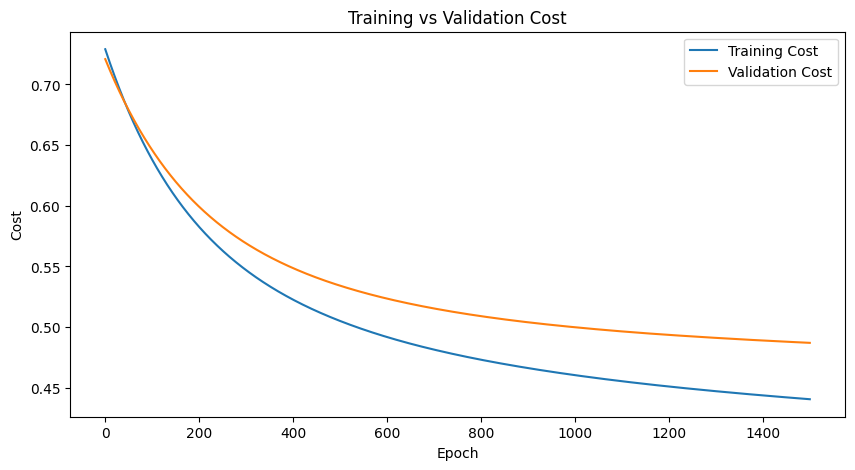

[I 2026-02-10 02:11:54,210] Trial 9 finished with value: 0.7597765363128449 and parameters: {'n_layers': 2, 'n_units_0': 54, 'n_units_1': 51, 'learning_rate': 0.0009965858584837471, 'lambda_reg': 1.7969889182904482e-05}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4870
Epoch 0001 | Train cost=0.7880 | Val cost=0.6906
  Train: acc=0.5205 prec=0.5804 rec=0.1481 f1=0.2359
  Val:   acc=0.6257 prec=0.5333 rec=0.2319 f1=0.3232


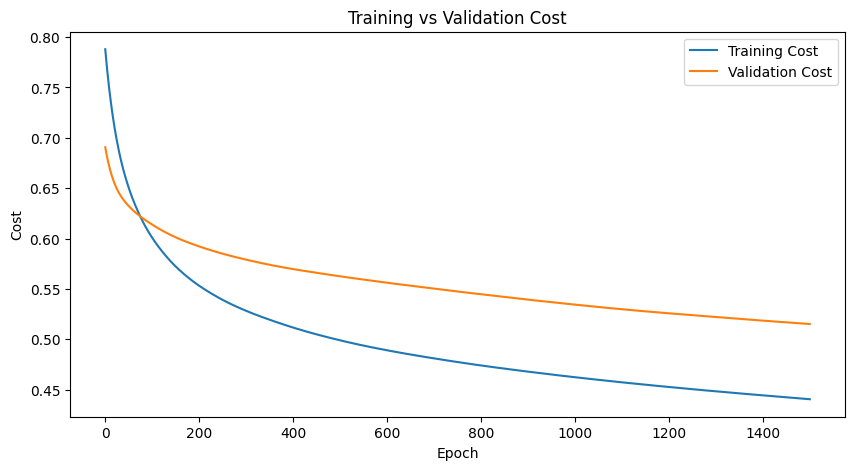

[I 2026-02-10 02:11:57,141] Trial 10 finished with value: 0.8044692737430122 and parameters: {'n_layers': 3, 'n_units_0': 14, 'n_units_1': 33, 'n_units_2': 11, 'learning_rate': 0.005457959657125463, 'lambda_reg': 0.07355618212722953}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5151
Epoch 0001 | Train cost=1.1593 | Val cost=1.4061
  Train: acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667
  Val:   acc=0.3911 prec=0.3876 rec=1.0000 f1=0.5587


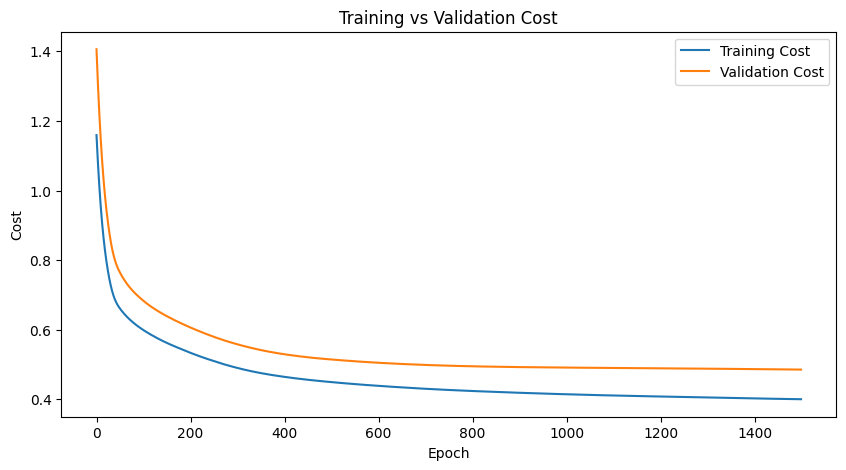

[I 2026-02-10 02:12:00,658] Trial 11 finished with value: 0.8100558659217832 and parameters: {'n_layers': 3, 'n_units_0': 15, 'n_units_1': 33, 'n_units_2': 8, 'learning_rate': 0.005311650977300345, 'lambda_reg': 0.08626537288655768}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4856
Epoch 0001 | Train cost=0.6897 | Val cost=0.7169
  Train: acc=0.5877 prec=0.6027 rec=0.5148 f1=0.5553
  Val:   acc=0.5419 prec=0.4133 rec=0.4493 f1=0.4306


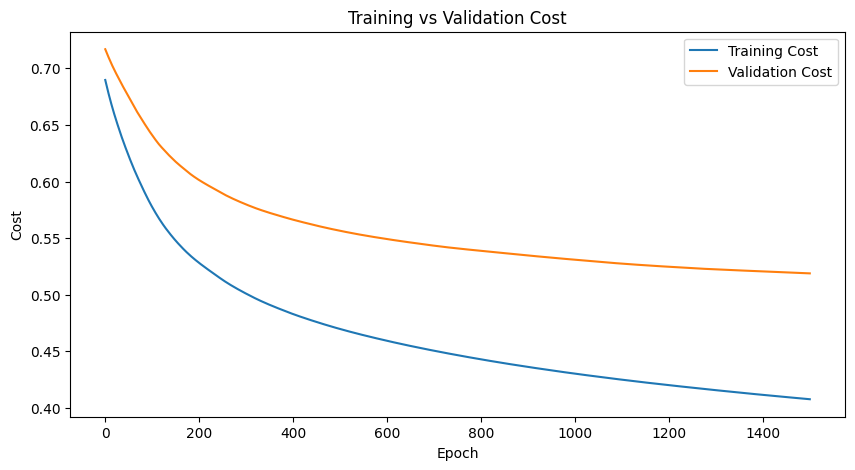

[I 2026-02-10 02:12:04,202] Trial 12 finished with value: 0.7709497206703868 and parameters: {'n_layers': 3, 'n_units_0': 23, 'n_units_1': 32, 'n_units_2': 8, 'learning_rate': 0.004146910049480432, 'lambda_reg': 0.0835918797838544}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5189
Epoch 0001 | Train cost=1.7596 | Val cost=1.5864
  Train: acc=0.5000 prec=0.0000 rec=0.0000 f1=0.0000
  Val:   acc=0.6145 prec=0.0000 rec=0.0000 f1=0.0000


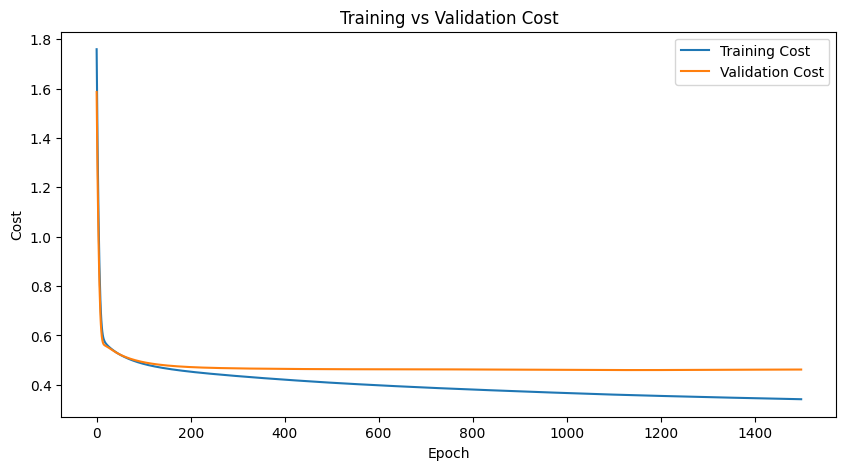

[I 2026-02-10 02:12:10,506] Trial 13 finished with value: 0.8044692737430122 and parameters: {'n_layers': 4, 'n_units_0': 23, 'n_units_1': 28, 'n_units_2': 24, 'n_units_3': 63, 'learning_rate': 0.010293336466331925, 'lambda_reg': 0.011324886802449316}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1133 with val_cost=0.4596
Epoch 0001 | Train cost=0.8128 | Val cost=0.9042
  Train: acc=0.4818 prec=0.4906 rec=0.9476 f1=0.6465
  Val:   acc=0.3799 prec=0.3793 rec=0.9565 f1=0.5432


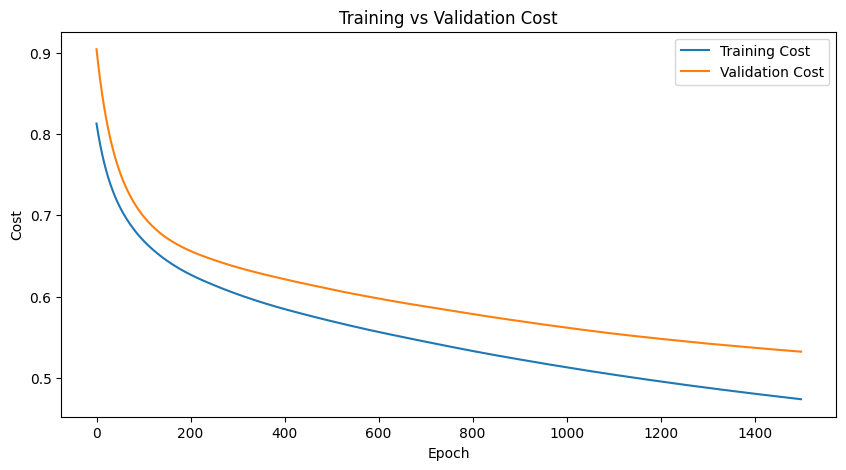

[I 2026-02-10 02:12:18,993] Trial 14 finished with value: 0.7932960893854705 and parameters: {'n_layers': 3, 'n_units_0': 9, 'n_units_1': 63, 'n_units_2': 22, 'learning_rate': 0.001904781627547939, 'lambda_reg': 0.016422712863633337}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5322
Epoch 0001 | Train cost=0.8025 | Val cost=0.7747
  Train: acc=0.3724 prec=0.2647 rec=0.1435 f1=0.1861
  Val:   acc=0.4134 prec=0.2353 rec=0.2319 f1=0.2336


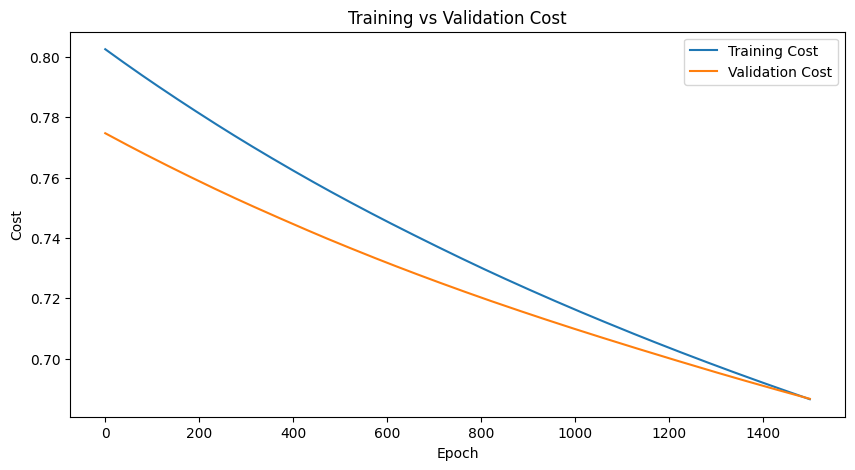

[I 2026-02-10 02:12:23,668] Trial 15 finished with value: 0.5530726256983209 and parameters: {'n_layers': 3, 'n_units_0': 25, 'n_units_1': 42, 'n_units_2': 23, 'learning_rate': 0.00010756236091120715, 'lambda_reg': 0.03044035938384525}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.6867
Epoch 0001 | Train cost=0.9559 | Val cost=0.9021
  Train: acc=0.4818 prec=0.3947 rec=0.0683 f1=0.1165
  Val:   acc=0.5531 prec=0.1765 rec=0.0435 f1=0.0698


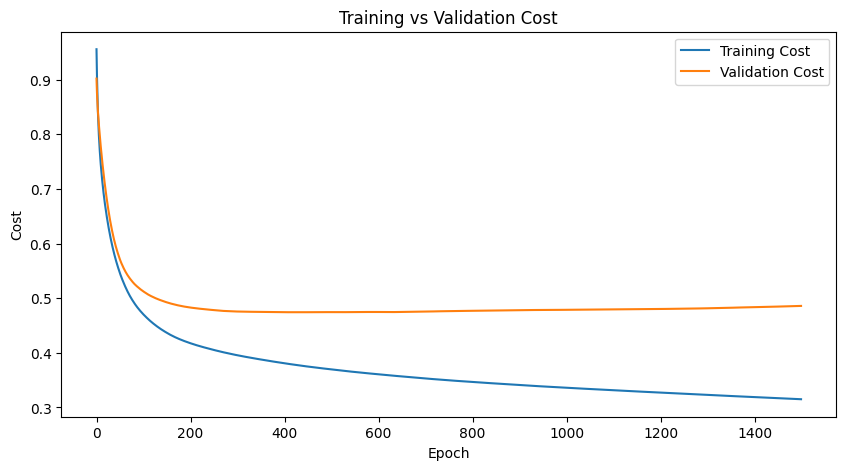

[I 2026-02-10 02:12:36,487] Trial 16 finished with value: 0.7765363128491577 and parameters: {'n_layers': 5, 'n_units_0': 33, 'n_units_1': 24, 'n_units_2': 38, 'n_units_3': 47, 'n_units_4': 64, 'learning_rate': 0.009912831730651658, 'lambda_reg': 0.0031488351423670565}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 429 with val_cost=0.4743
Epoch 0001 | Train cost=0.7307 | Val cost=0.7049
  Train: acc=0.4260 prec=0.3962 rec=0.2825 f1=0.3298
  Val:   acc=0.5251 prec=0.3710 rec=0.3333 f1=0.3511


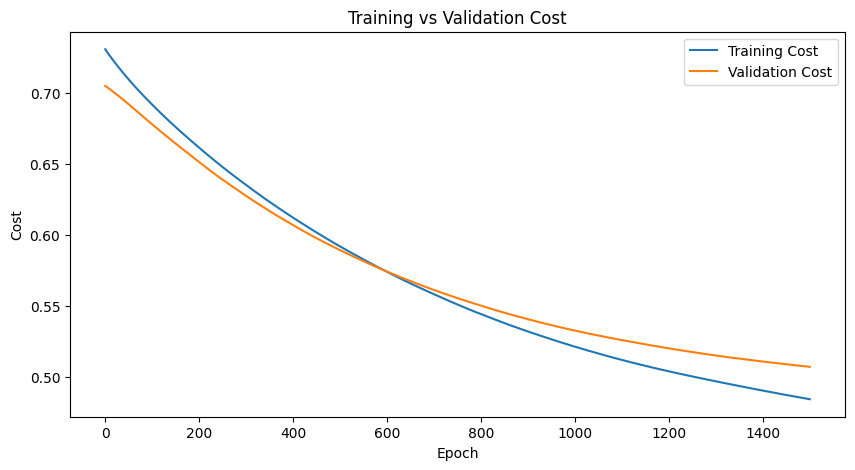

[I 2026-02-10 02:12:41,041] Trial 17 finished with value: 0.754189944134074 and parameters: {'n_layers': 4, 'n_units_0': 18, 'n_units_1': 39, 'n_units_2': 14, 'n_units_3': 8, 'learning_rate': 0.0017398104689252435, 'lambda_reg': 0.005000254552298776}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5071
Epoch 0001 | Train cost=0.7659 | Val cost=0.7801
  Train: acc=0.3713 prec=0.3975 rec=0.4989 f1=0.4424
  Val:   acc=0.3464 prec=0.2966 rec=0.5072 f1=0.3743


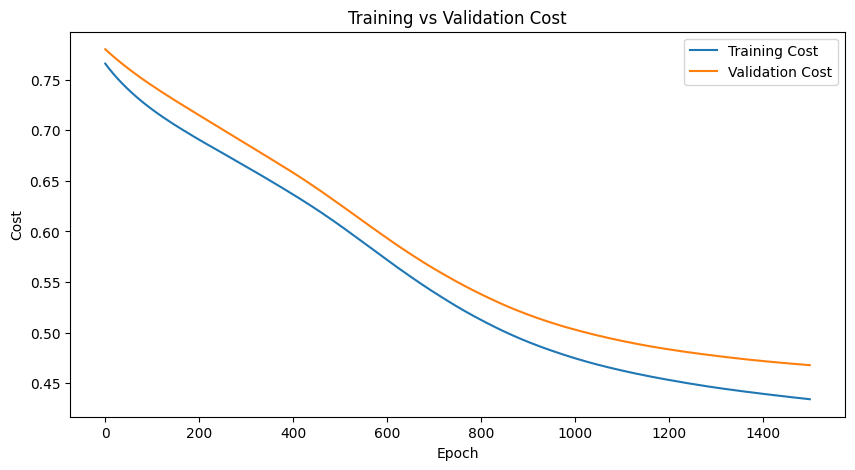

[I 2026-02-10 02:12:42,996] Trial 18 finished with value: 0.7877094972066996 and parameters: {'n_layers': 2, 'n_units_0': 8, 'n_units_1': 10, 'learning_rate': 0.007967253619768765, 'lambda_reg': 0.03821300888871054}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4678
Epoch 0001 | Train cost=0.9486 | Val cost=0.9918
  Train: acc=0.3679 prec=0.3854 rec=0.4442 f1=0.4127
  Val:   acc=0.3464 prec=0.2778 rec=0.4348 f1=0.3390


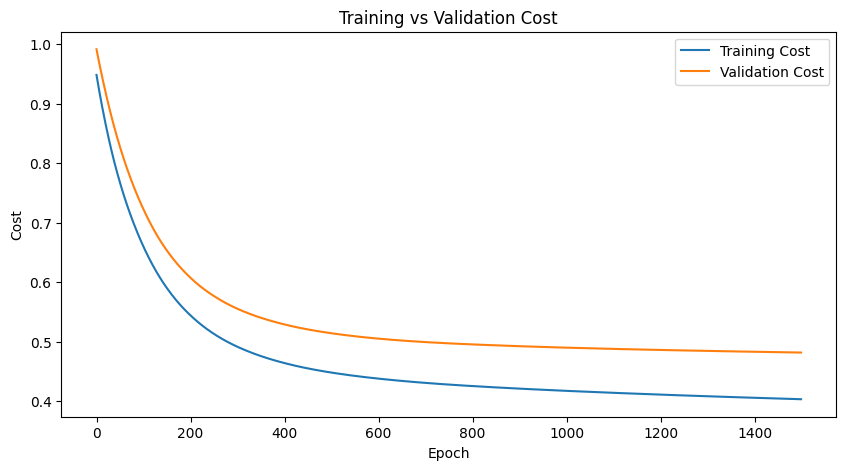

[I 2026-02-10 02:12:49,940] Trial 19 finished with value: 0.7988826815642414 and parameters: {'n_layers': 3, 'n_units_0': 37, 'n_units_1': 26, 'n_units_2': 35, 'learning_rate': 0.0022297653864793944, 'lambda_reg': 0.027814904219547548}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4817
Epoch 0001 | Train cost=0.9650 | Val cost=1.0645
  Train: acc=0.4487 prec=0.4713 rec=0.8405 f1=0.6039
  Val:   acc=0.3911 prec=0.3750 rec=0.8696 f1=0.5240


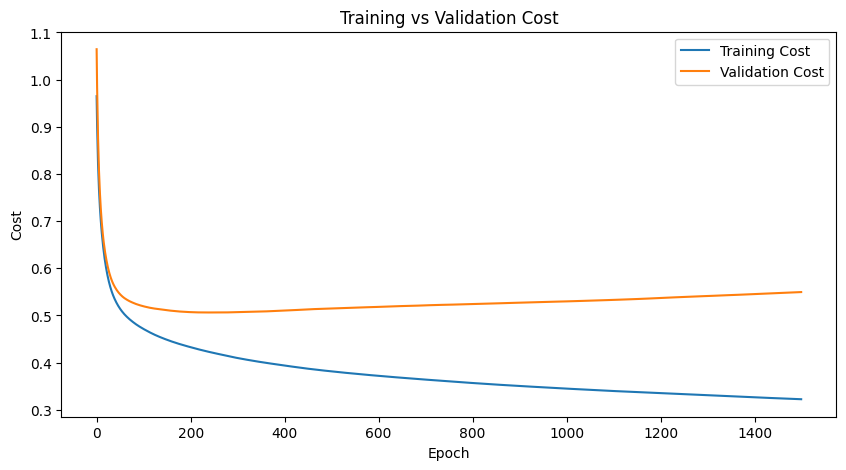

[I 2026-02-10 02:12:54,527] Trial 20 finished with value: 0.7821229050279286 and parameters: {'n_layers': 4, 'n_units_0': 17, 'n_units_1': 41, 'n_units_2': 16, 'n_units_3': 34, 'learning_rate': 0.021269791686625922, 'lambda_reg': 0.07238758113895837}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 259 with val_cost=0.5062
Epoch 0001 | Train cost=1.1226 | Val cost=1.3384
  Train: acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667
  Val:   acc=0.3855 prec=0.3855 rec=1.0000 f1=0.5565


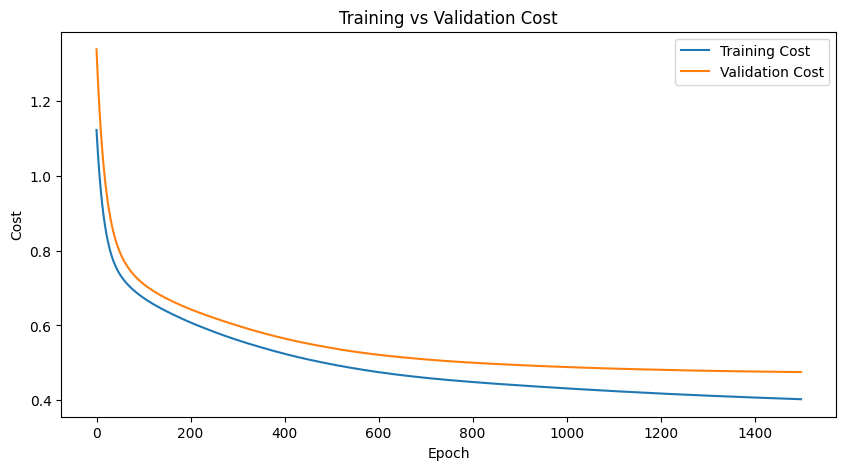

[I 2026-02-10 02:13:00,233] Trial 21 finished with value: 0.8100558659217832 and parameters: {'n_layers': 3, 'n_units_0': 16, 'n_units_1': 35, 'n_units_2': 9, 'learning_rate': 0.006869677292455069, 'lambda_reg': 0.08388029176944771}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4754
Epoch 0001 | Train cost=1.2429 | Val cost=1.5798
  Train: acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667
  Val:   acc=0.3855 prec=0.3855 rec=1.0000 f1=0.5565


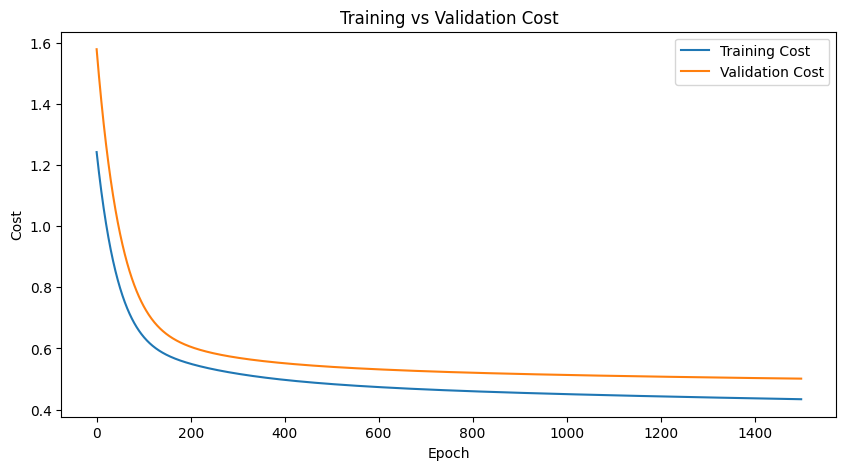

[I 2026-02-10 02:13:12,856] Trial 22 finished with value: 0.7932960893854705 and parameters: {'n_layers': 2, 'n_units_0': 20, 'n_units_1': 35, 'learning_rate': 0.004129572453120875, 'lambda_reg': 0.03538867797911161}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5011
Epoch 0001 | Train cost=0.6875 | Val cost=0.6728
  Train: acc=0.5786 prec=0.6353 rec=0.3690 f1=0.4669
  Val:   acc=0.5866 prec=0.4490 rec=0.3188 f1=0.3729


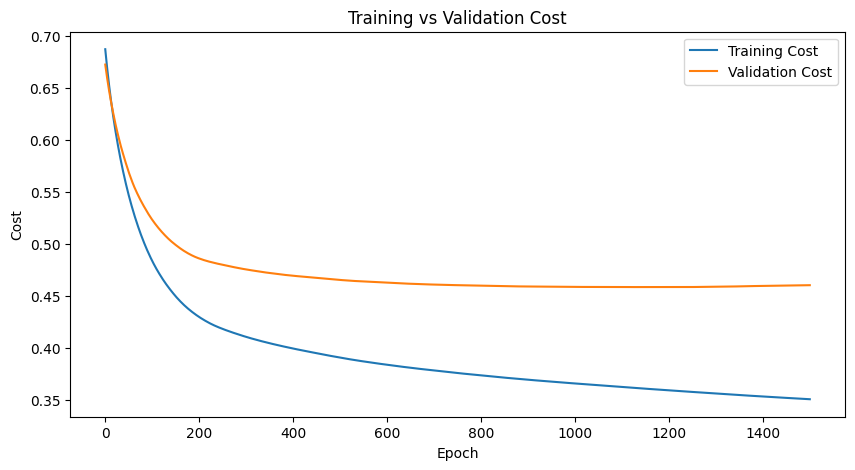

[I 2026-02-10 02:13:19,781] Trial 23 finished with value: 0.7877094972066996 and parameters: {'n_layers': 3, 'n_units_0': 29, 'n_units_1': 22, 'n_units_2': 8, 'learning_rate': 0.011422642349098473, 'lambda_reg': 0.005487395224360249}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1217 with val_cost=0.4583
Epoch 0001 | Train cost=0.6592 | Val cost=0.6998
  Train: acc=0.6025 prec=0.5918 rec=0.6606 f1=0.6243
  Val:   acc=0.6145 prec=0.5000 rec=0.6522 f1=0.5660


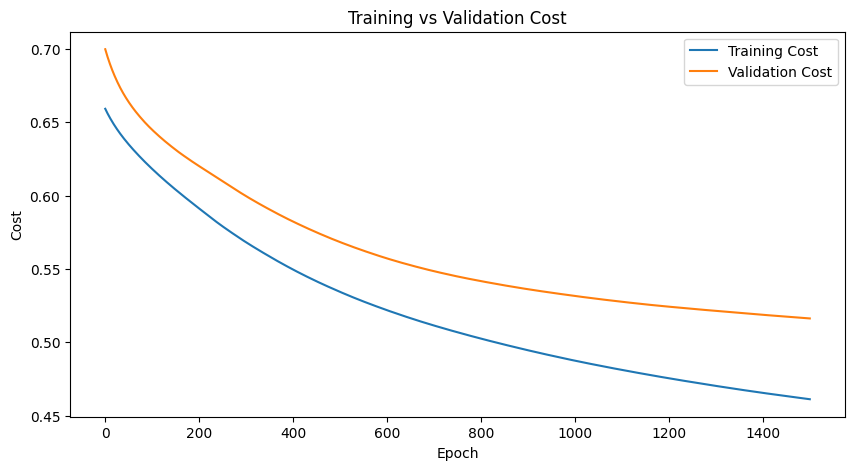

[I 2026-02-10 02:13:23,216] Trial 24 finished with value: 0.8044692737430122 and parameters: {'n_layers': 3, 'n_units_0': 13, 'n_units_1': 30, 'n_units_2': 18, 'learning_rate': 0.003077729195001618, 'lambda_reg': 0.08876386734243297}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5163
Epoch 0001 | Train cost=1.3249 | Val cost=1.1041
  Train: acc=0.5000 prec=0.0000 rec=0.0000 f1=0.0000
  Val:   acc=0.6145 prec=0.0000 rec=0.0000 f1=0.0000


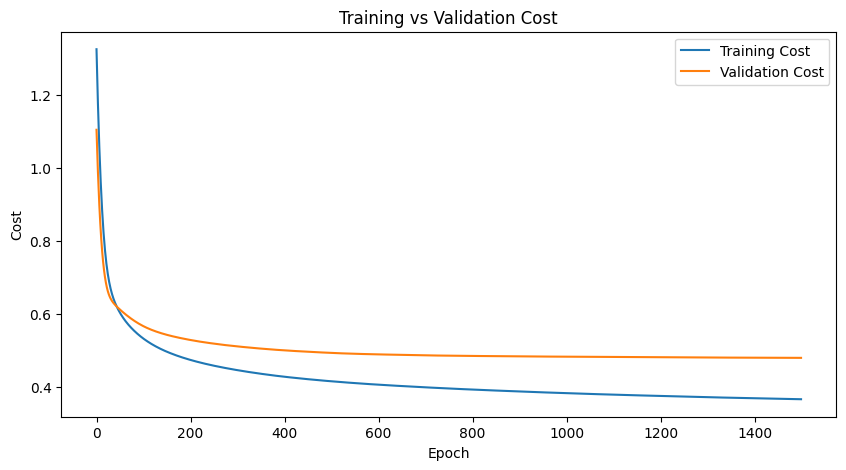

[I 2026-02-10 02:13:39,782] Trial 25 finished with value: 0.7821229050279286 and parameters: {'n_layers': 3, 'n_units_0': 28, 'n_units_1': 45, 'n_units_2': 34, 'learning_rate': 0.00649859174525578, 'lambda_reg': 0.023414234770934603}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4791
Epoch 0001 | Train cost=1.1820 | Val cost=1.4301
  Train: acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667
  Val:   acc=0.3855 prec=0.3855 rec=1.0000 f1=0.5565


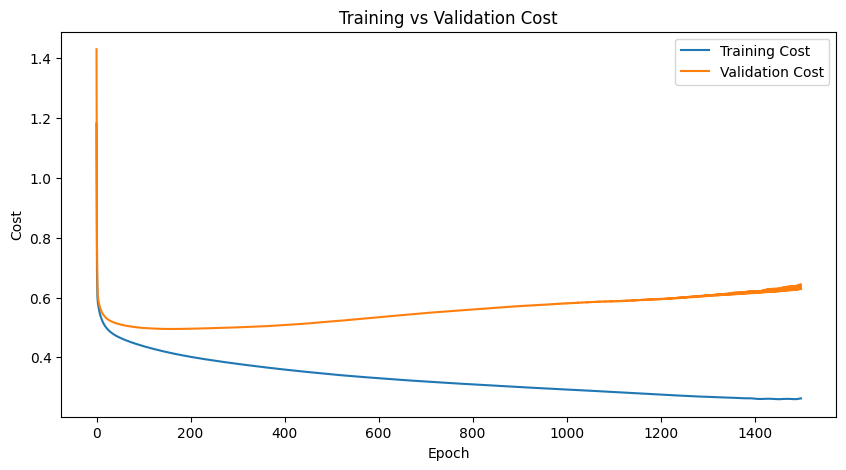

[I 2026-02-10 02:13:50,409] Trial 26 finished with value: 0.7709497206703868 and parameters: {'n_layers': 4, 'n_units_0': 20, 'n_units_1': 38, 'n_units_2': 28, 'n_units_3': 47, 'learning_rate': 0.039910339481985, 'lambda_reg': 0.04542838401383304}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 159 with val_cost=0.4948
Epoch 0001 | Train cost=1.0411 | Val cost=1.2326
  Train: acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667
  Val:   acc=0.3855 prec=0.3855 rec=1.0000 f1=0.5565


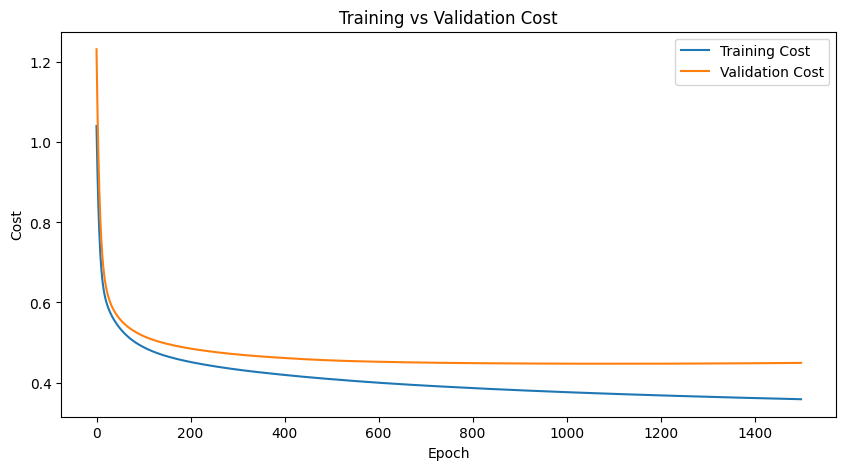

[I 2026-02-10 02:13:53,744] Trial 27 finished with value: 0.7932960893854705 and parameters: {'n_layers': 2, 'n_units_0': 16, 'n_units_1': 60, 'learning_rate': 0.01620264069741779, 'lambda_reg': 0.012502592949435185}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1080 with val_cost=0.4470
Epoch 0001 | Train cost=0.8364 | Val cost=0.9883
  Train: acc=0.4795 prec=0.4886 rec=0.8770 f1=0.6275
  Val:   acc=0.3631 prec=0.3636 rec=0.8696 f1=0.5128


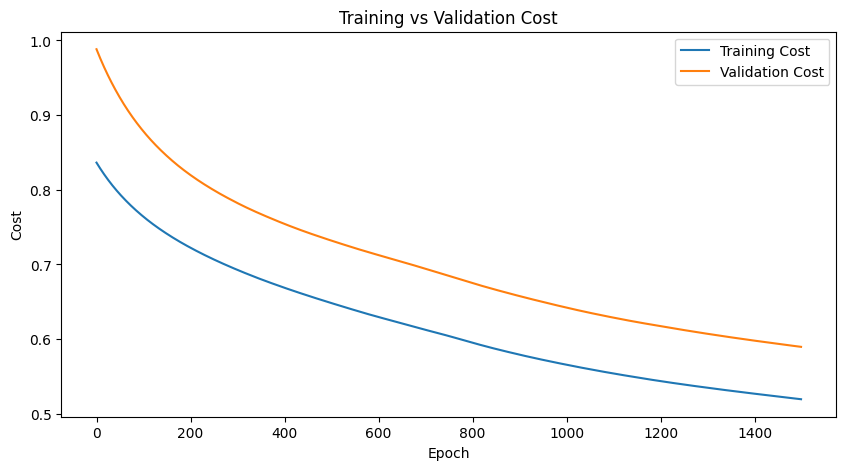

[I 2026-02-10 02:13:56,817] Trial 28 finished with value: 0.7709497206703868 and parameters: {'n_layers': 3, 'n_units_0': 11, 'n_units_1': 35, 'n_units_2': 15, 'learning_rate': 0.001452055843548334, 'lambda_reg': 0.09993916268885104}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5897
Epoch 0001 | Train cost=0.8747 | Val cost=0.9275
  Train: acc=0.4282 prec=0.4548 rec=0.7221 f1=0.5581
  Val:   acc=0.3575 prec=0.3403 rec=0.7101 f1=0.4601


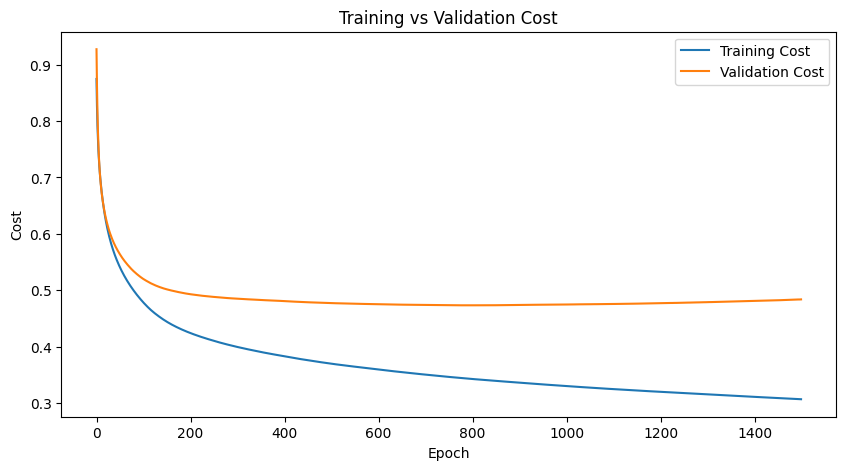

[I 2026-02-10 02:14:07,183] Trial 29 finished with value: 0.7821229050279286 and parameters: {'n_layers': 4, 'n_units_0': 33, 'n_units_1': 20, 'n_units_2': 46, 'n_units_3': 24, 'learning_rate': 0.015215689180700712, 'lambda_reg': 0.0024557178612860794}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 823 with val_cost=0.4731
Epoch 0001 | Train cost=1.0667 | Val cost=1.1961
  Train: acc=0.4954 prec=0.4977 rec=0.9886 f1=0.6621
  Val:   acc=0.3855 prec=0.3855 rec=1.0000 f1=0.5565


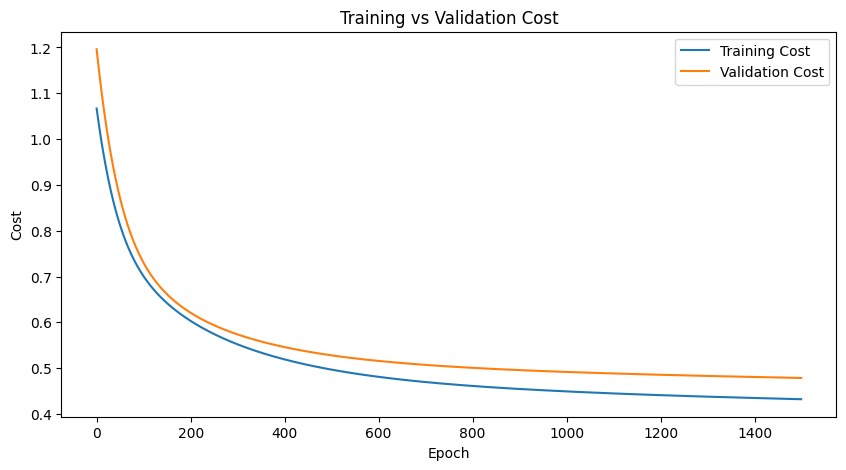

[I 2026-02-10 02:14:19,202] Trial 30 finished with value: 0.7932960893854705 and parameters: {'n_layers': 2, 'n_units_0': 26, 'n_units_1': 28, 'learning_rate': 0.002818271003951291, 'lambda_reg': 0.017486202136627382}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4786
Epoch 0001 | Train cost=0.9040 | Val cost=1.0723
  Train: acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667
  Val:   acc=0.3855 prec=0.3855 rec=1.0000 f1=0.5565


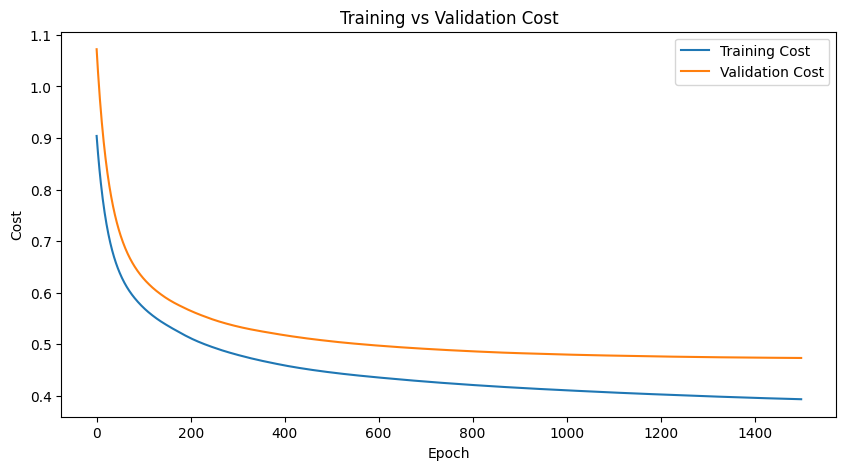

[I 2026-02-10 02:14:21,972] Trial 31 finished with value: 0.7988826815642414 and parameters: {'n_layers': 3, 'n_units_0': 15, 'n_units_1': 33, 'n_units_2': 9, 'learning_rate': 0.006373306211912738, 'lambda_reg': 0.05089523889892944}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4731
Epoch 0001 | Train cost=0.8016 | Val cost=0.8786
  Train: acc=0.4658 prec=0.4770 rec=0.7084 f1=0.5701
  Val:   acc=0.3855 prec=0.3546 rec=0.7246 f1=0.4762


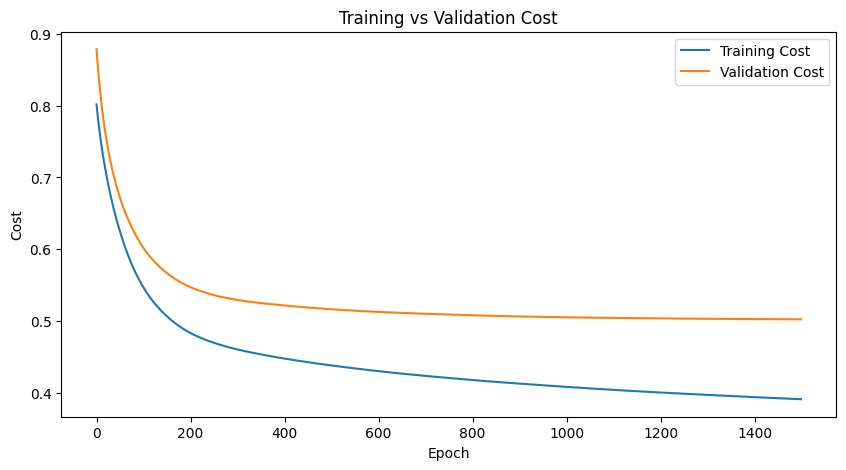

[I 2026-02-10 02:14:27,148] Trial 32 finished with value: 0.7765363128491577 and parameters: {'n_layers': 3, 'n_units_0': 22, 'n_units_1': 31, 'n_units_2': 12, 'learning_rate': 0.005674348280961596, 'lambda_reg': 0.050491169522005046}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5022
Epoch 0001 | Train cost=1.1194 | Val cost=1.0415
  Train: acc=0.3417 prec=0.2337 rec=0.1390 f1=0.1743
  Val:   acc=0.4246 prec=0.2069 rec=0.1739 f1=0.1890


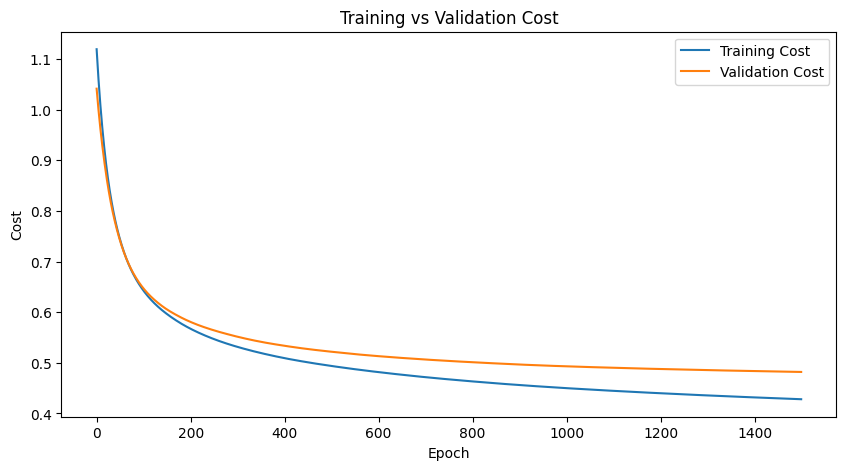

[I 2026-02-10 02:14:33,587] Trial 33 finished with value: 0.8100558659217832 and parameters: {'n_layers': 3, 'n_units_0': 12, 'n_units_1': 46, 'n_units_2': 19, 'learning_rate': 0.00440785336841563, 'lambda_reg': 0.05475523890350365}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.4819
Epoch 0001 | Train cost=0.7959 | Val cost=0.9151
  Train: acc=0.4579 prec=0.4759 rec=0.8337 f1=0.6060
  Val:   acc=0.3631 prec=0.3620 rec=0.8551 f1=0.5086


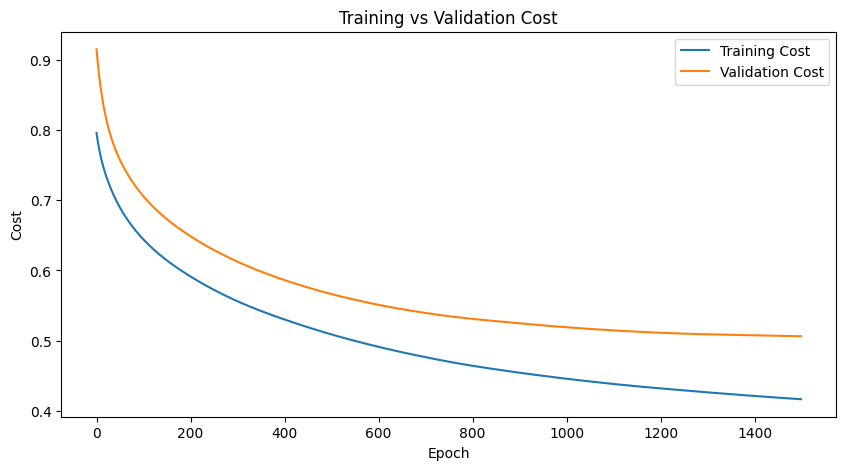

[I 2026-02-10 02:14:39,929] Trial 34 finished with value: 0.7821229050279286 and parameters: {'n_layers': 4, 'n_units_0': 11, 'n_units_1': 53, 'n_units_2': 20, 'n_units_3': 46, 'learning_rate': 0.003620292671696116, 'lambda_reg': 0.02054391197258891}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5063
Epoch 0001 | Train cost=0.7440 | Val cost=0.7521
  Train: acc=0.4852 prec=0.4895 rec=0.6902 f1=0.5728
  Val:   acc=0.3966 prec=0.3388 rec=0.5942 f1=0.4316


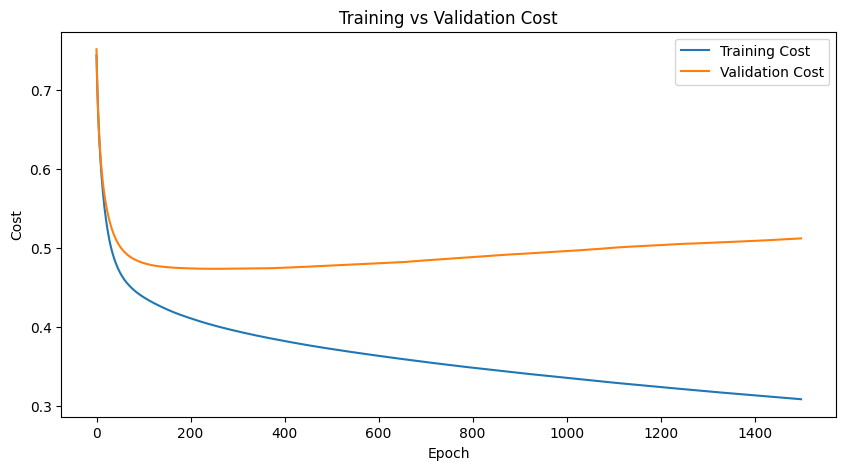

[I 2026-02-10 02:14:48,435] Trial 35 finished with value: 0.7821229050279286 and parameters: {'n_layers': 3, 'n_units_0': 18, 'n_units_1': 43, 'n_units_2': 29, 'learning_rate': 0.02815506566333224, 'lambda_reg': 0.01008839066010535}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 246 with val_cost=0.4738
Epoch 0001 | Train cost=0.8015 | Val cost=0.7703
  Train: acc=0.5000 prec=0.0000 rec=0.0000 f1=0.0000
  Val:   acc=0.6145 prec=0.0000 rec=0.0000 f1=0.0000


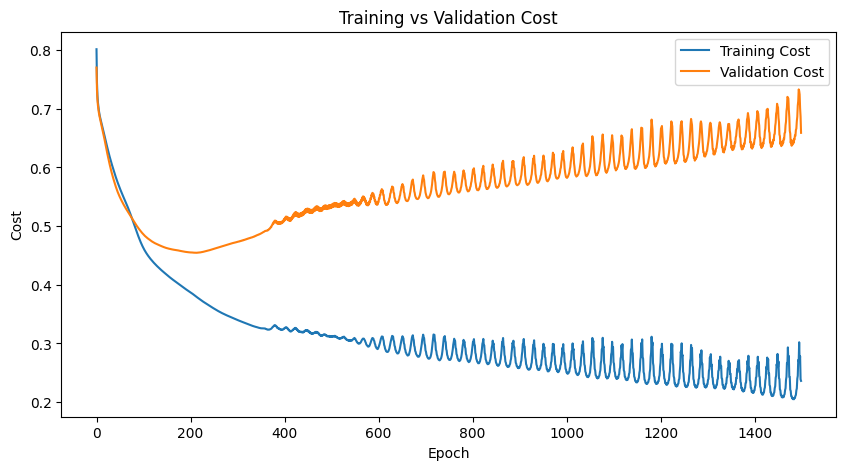

[I 2026-02-10 02:14:53,805] Trial 36 finished with value: 0.7709497206703868 and parameters: {'n_layers': 5, 'n_units_0': 12, 'n_units_1': 46, 'n_units_2': 17, 'n_units_3': 38, 'n_units_4': 8, 'learning_rate': 0.06535345326719537, 'lambda_reg': 0.0011591486906833133}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 213 with val_cost=0.4546
Epoch 0001 | Train cost=0.7493 | Val cost=0.9267
  Train: acc=0.6560 prec=0.6003 rec=0.9339 f1=0.7308
  Val:   acc=0.5978 prec=0.4887 rec=0.9420 f1=0.6436


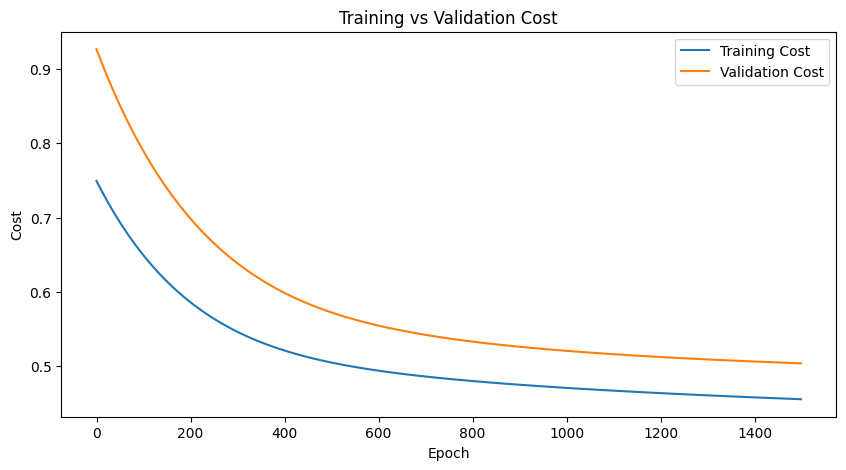

[I 2026-02-10 02:14:55,587] Trial 37 finished with value: 0.754189944134074 and parameters: {'n_layers': 1, 'n_units_0': 37, 'learning_rate': 0.0011933434347457935, 'lambda_reg': 0.006439283614161352}. Best is trial 2 with value: 0.8100558659217832.


Best checkpoint saved at epoch 1500 with val_cost=0.5036
Epoch 0001 | Train cost=0.8794 | Val cost=0.8927
  Train: acc=0.4305 prec=0.4421 rec=0.5308 f1=0.4824
  Val:   acc=0.4190 prec=0.3333 rec=0.5072 f1=0.4023


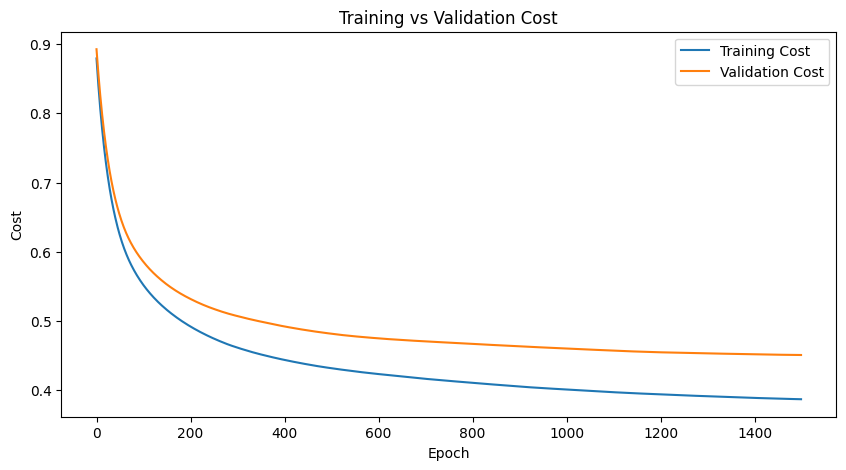

[I 2026-02-10 02:14:58,712] Trial 38 finished with value: 0.821229050279325 and parameters: {'n_layers': 2, 'n_units_0': 8, 'n_units_1': 57, 'learning_rate': 0.012267983419257809, 'lambda_reg': 0.00034071465666215135}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4506
Epoch 0001 | Train cost=0.8569 | Val cost=0.9557
  Train: acc=0.5194 prec=0.5101 rec=0.9818 f1=0.6713
  Val:   acc=0.4190 prec=0.3977 rec=0.9855 f1=0.5667


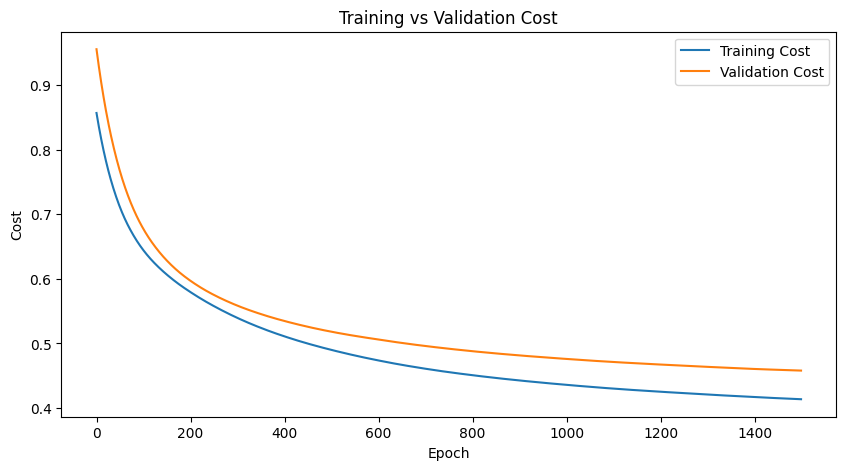

[I 2026-02-10 02:15:00,430] Trial 39 finished with value: 0.7988826815642414 and parameters: {'n_layers': 1, 'n_units_0': 8, 'learning_rate': 0.012783282915982814, 'lambda_reg': 0.00047976326767635934}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4579
Epoch 0001 | Train cost=0.9504 | Val cost=0.8235
  Train: acc=0.4749 prec=0.3804 rec=0.0797 f1=0.1318
  Val:   acc=0.5531 prec=0.2963 rec=0.1159 f1=0.1667


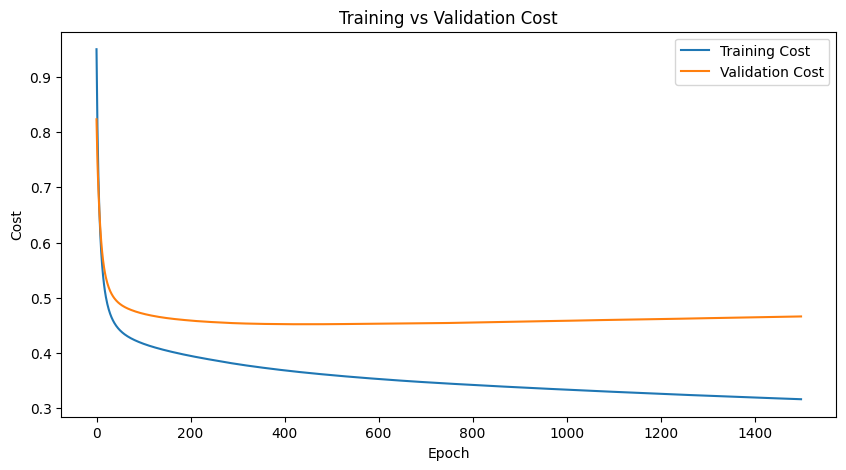

[I 2026-02-10 02:15:04,350] Trial 40 finished with value: 0.7932960893854705 and parameters: {'n_layers': 2, 'n_units_0': 33, 'n_units_1': 55, 'learning_rate': 0.03298323530048454, 'lambda_reg': 0.0005273504503670371}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 454 with val_cost=0.4519
Epoch 0001 | Train cost=1.1297 | Val cost=0.9747
  Train: acc=0.3440 prec=0.2415 rec=0.1458 f1=0.1818
  Val:   acc=0.4302 prec=0.2105 rec=0.1739 f1=0.1905


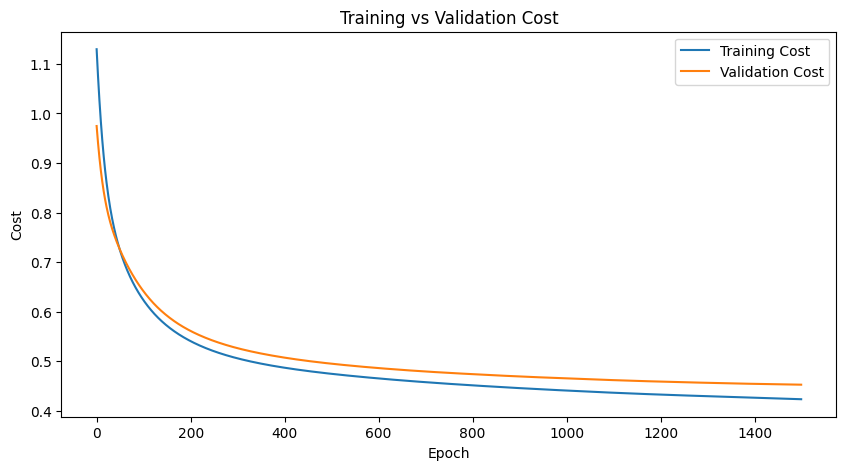

[I 2026-02-10 02:15:06,676] Trial 41 finished with value: 0.8044692737430122 and parameters: {'n_layers': 2, 'n_units_0': 11, 'n_units_1': 48, 'learning_rate': 0.007408346854607909, 'lambda_reg': 0.00019668082236758884}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4528
Epoch 0001 | Train cost=0.9907 | Val cost=0.9809
  Train: acc=0.3155 prec=0.3386 rec=0.3872 f1=0.3613
  Val:   acc=0.3128 prec=0.2353 rec=0.3478 f1=0.2807


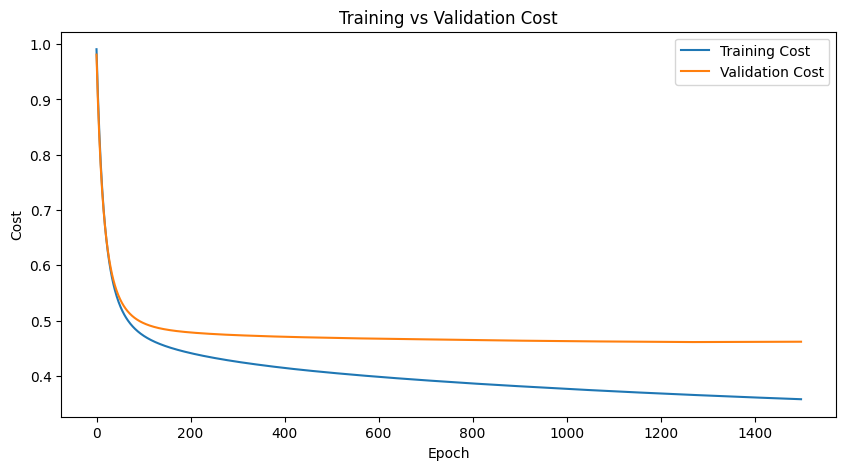

[I 2026-02-10 02:15:10,840] Trial 42 finished with value: 0.7877094972066996 and parameters: {'n_layers': 2, 'n_units_0': 20, 'n_units_1': 56, 'learning_rate': 0.018735376821465897, 'lambda_reg': 0.00021604815257087533}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1262 with val_cost=0.4613
Epoch 0001 | Train cost=0.9032 | Val cost=0.9246
  Train: acc=0.3041 prec=0.3595 rec=0.5011 f1=0.4186
  Val:   acc=0.2793 prec=0.2794 rec=0.5507 f1=0.3707


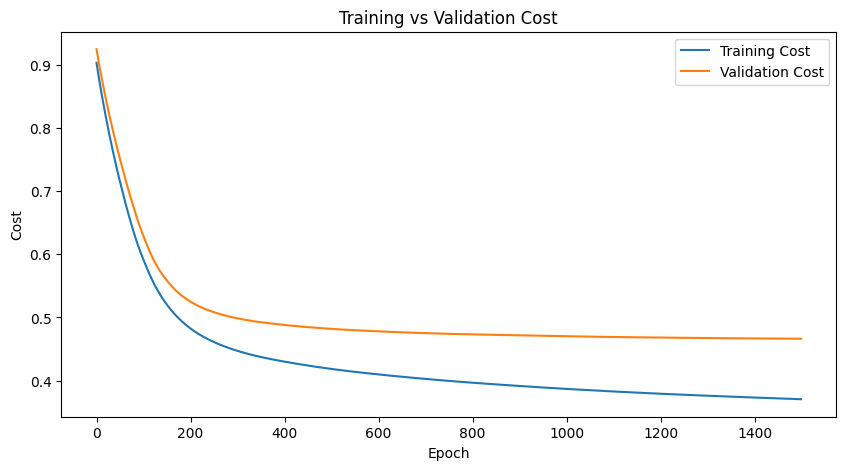

[I 2026-02-10 02:15:19,847] Trial 43 finished with value: 0.7821229050279286 and parameters: {'n_layers': 3, 'n_units_0': 63, 'n_units_1': 38, 'n_units_2': 11, 'learning_rate': 0.004376466148988608, 'lambda_reg': 0.00011918225354240772}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4663
Epoch 0001 | Train cost=0.6934 | Val cost=0.6172
  Train: acc=0.5296 prec=0.6354 rec=0.1390 f1=0.2280
  Val:   acc=0.6201 prec=0.5263 rec=0.1449 f1=0.2273


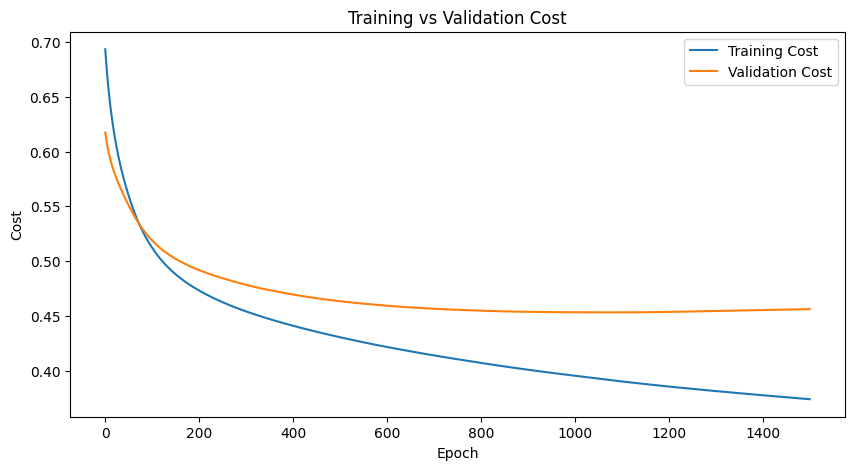

[I 2026-02-10 02:15:24,664] Trial 44 finished with value: 0.8044692737430122 and parameters: {'n_layers': 3, 'n_units_0': 15, 'n_units_1': 50, 'n_units_2': 27, 'learning_rate': 0.008470104836360636, 'lambda_reg': 3.323660048477576e-05}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1096 with val_cost=0.4532
Epoch 0001 | Train cost=0.8261 | Val cost=0.8392
  Train: acc=0.3622 prec=0.3737 rec=0.4077 f1=0.3900
  Val:   acc=0.3575 prec=0.2700 rec=0.3913 f1=0.3195


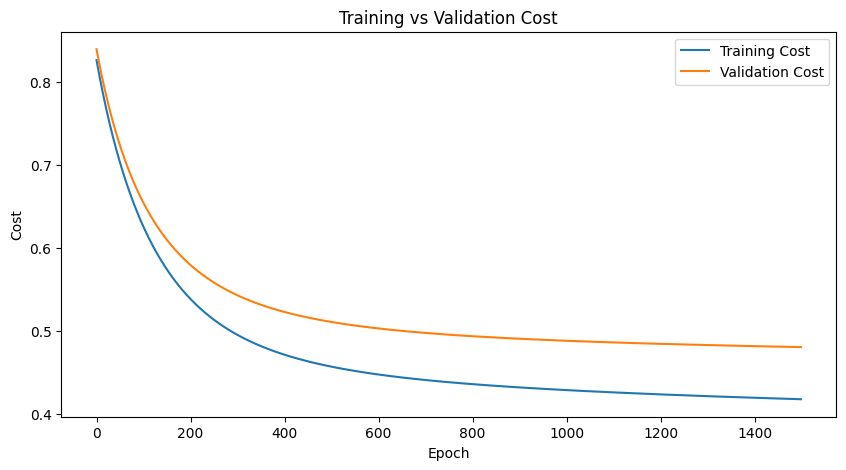

[I 2026-02-10 02:15:26,861] Trial 45 finished with value: 0.7821229050279286 and parameters: {'n_layers': 1, 'n_units_0': 41, 'learning_rate': 0.004912415792733269, 'lambda_reg': 0.0598889343993395}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4807
Epoch 0001 | Train cost=0.6080 | Val cost=0.6337
  Train: acc=0.7039 prec=0.6908 rec=0.7380 f1=0.7137
  Val:   acc=0.6816 prec=0.5667 rec=0.7391 f1=0.6415


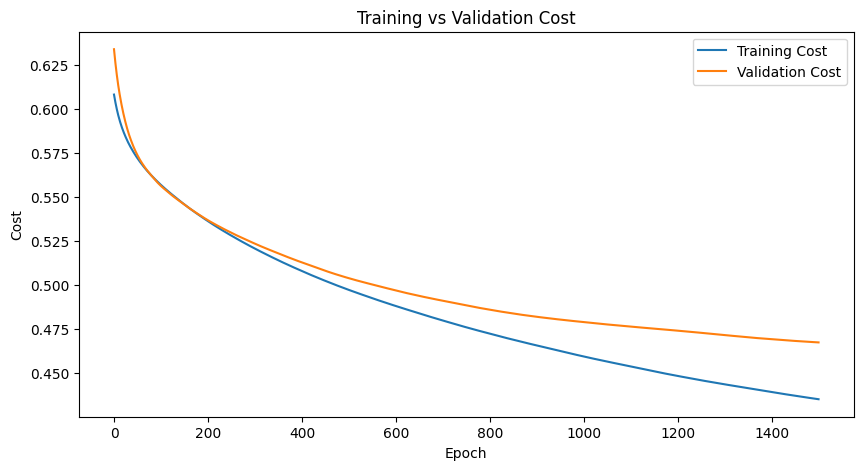

[I 2026-02-10 02:15:34,323] Trial 46 finished with value: 0.7932960893854705 and parameters: {'n_layers': 4, 'n_units_0': 10, 'n_units_1': 58, 'n_units_2': 14, 'n_units_3': 20, 'learning_rate': 0.002464273542235368, 'lambda_reg': 6.652656008331776e-05}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4673
Epoch 0001 | Train cost=0.9077 | Val cost=0.9161
  Train: acc=0.3702 prec=0.4219 rec=0.7016 f1=0.5269
  Val:   acc=0.3408 prec=0.3497 rec=0.8261 f1=0.4914


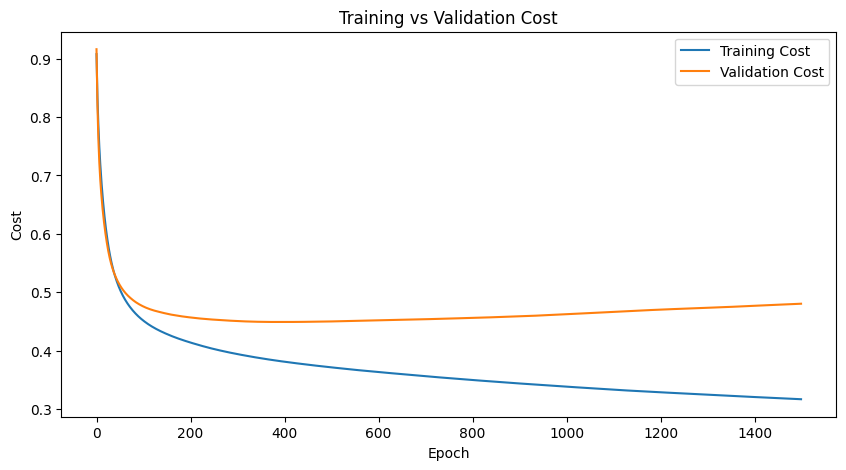

[I 2026-02-10 02:15:38,127] Trial 47 finished with value: 0.7709497206703868 and parameters: {'n_layers': 3, 'n_units_0': 24, 'n_units_1': 36, 'n_units_2': 19, 'learning_rate': 0.023148686997814343, 'lambda_reg': 0.0007114653475941628}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 402 with val_cost=0.4492
Epoch 0001 | Train cost=0.8226 | Val cost=0.8917
  Train: acc=0.4670 prec=0.4760 rec=0.6560 f1=0.5517
  Val:   acc=0.4525 prec=0.3739 rec=0.6232 f1=0.4674


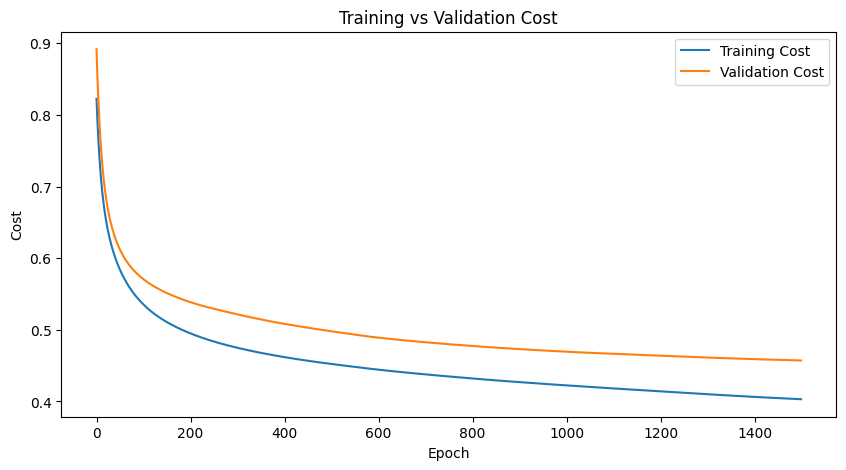

[I 2026-02-10 02:15:40,267] Trial 48 finished with value: 0.7988826815642414 and parameters: {'n_layers': 2, 'n_units_0': 14, 'n_units_1': 26, 'learning_rate': 0.013600228358605367, 'lambda_reg': 0.0018536013906879213}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1500 with val_cost=0.4573
Epoch 0001 | Train cost=0.7391 | Val cost=0.7462
  Train: acc=0.4282 prec=0.4395 rec=0.5216 f1=0.4771
  Val:   acc=0.4078 prec=0.3204 rec=0.4783 f1=0.3837


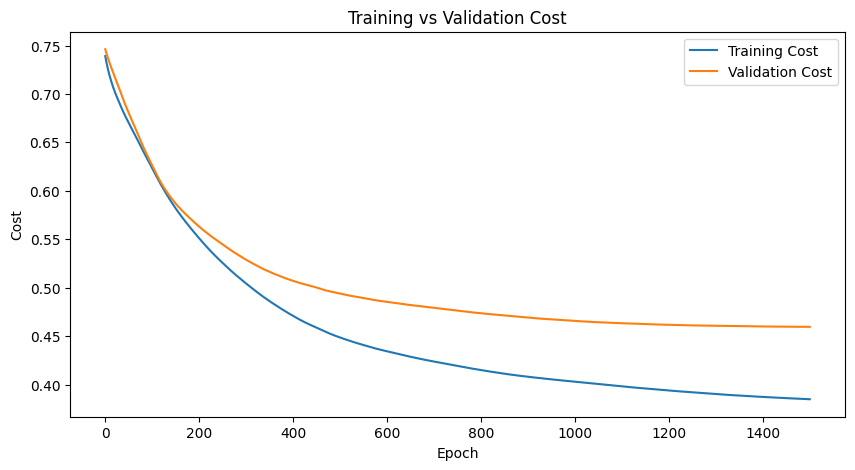

[I 2026-02-10 02:15:48,369] Trial 49 finished with value: 0.7932960893854705 and parameters: {'n_layers': 4, 'n_units_0': 8, 'n_units_1': 64, 'n_units_2': 12, 'n_units_3': 8, 'learning_rate': 0.009071680674830718, 'lambda_reg': 0.0002658098801594963}. Best is trial 38 with value: 0.821229050279325.


Best checkpoint saved at epoch 1499 with val_cost=0.4595
Best trial: 38
Best params: {'n_layers': 2, 'n_units_0': 8, 'n_units_1': 57, 'learning_rate': 0.012267983419257809, 'lambda_reg': 0.00034071465666215135}
Best accuracy: 0.821229050279325


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:", study.best_trial.number)
print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

# About TPE
The **Tree-structured Parzen Estimator (TPE)** is a Bayesian optimization algorithm used by Optuna for hyperparameter tuning. It starts with an initial phase of random sampling, controlled by the `n_startup_trials` parameter. During this phase, hyperparameter values are sampled uniformly to collect an unbiased and diverse set of observations across the search space.

After the random sampling phase, TPE transitions to a more informed search strategy. It models two probability distributions: one representing hyperparameter configurations from the best-performing trials (considered *successful*), and another representing the remaining trials (considered *unsuccessful*). New hyperparameter values are then sampled by maximizing the ratio between these two distributions, favoring configurations that are more likely to improve performance. This strategy enables TPE to efficiently explore the search space and progressively converge toward optimal hyperparameter values.


# Best trial

In [ ]:
print("Best validation accuracy:", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best validation accuracy: 0.821229050279325
Best hyperparameters:
  n_layers: 2
  n_units_0: 8
  n_units_1: 57
  learning_rate: 0.012267983419257809
  lambda_reg: 0.00034071465666215135


# Rebuild the Best Architecture

In [ ]:
best_params = study.best_params

n_layers = best_params["n_layers"]
hidden_units = [best_params[f"n_units_{i}"] for i in range(n_layers)]

best_layer_dims = [X_train_mlp.shape[0]] + hidden_units + [1]
best_layer_dims

[8, 8, 57, 1]

# Retrain a Final Clean Model

Epoch 0001 | Train cost=0.8794 | Val cost=0.8927
  Train: acc=0.4305 prec=0.4421 rec=0.5308 f1=0.4824
  Val:   acc=0.4190 prec=0.3333 rec=0.5072 f1=0.4023
Epoch 0100 | Train cost=0.5525 | Val cost=0.5859
  Train: acc=0.7597 prec=0.7556 rec=0.7677 f1=0.7616
  Val:   acc=0.7318 prec=0.6329 rec=0.7246 f1=0.6757
Epoch 0200 | Train cost=0.4921 | Val cost=0.5319
  Train: acc=0.7836 prec=0.7810 rec=0.7882 f1=0.7846
  Val:   acc=0.7598 prec=0.6625 rec=0.7681 f1=0.7114
Epoch 0300 | Train cost=0.4614 | Val cost=0.5070
  Train: acc=0.7927 prec=0.7981 rec=0.7836 f1=0.7908
  Val:   acc=0.7821 prec=0.6974 rec=0.7681 f1=0.7310
Epoch 0400 | Train cost=0.4436 | Val cost=0.4920
  Train: acc=0.7984 prec=0.8090 rec=0.7813 f1=0.7949
  Val:   acc=0.8045 prec=0.7500 rec=0.7391 f1=0.7445
Epoch 0500 | Train cost=0.4315 | Val cost=0.4814
  Train: acc=0.8075 prec=0.8230 rec=0.7836 f1=0.8028
  Val:   acc=0.8156 prec=0.7571 rec=0.7681 f1=0.7626
Epoch 0600 | Train cost=0.4231 | Val cost=0.4747
  Train: acc=0.8144 p

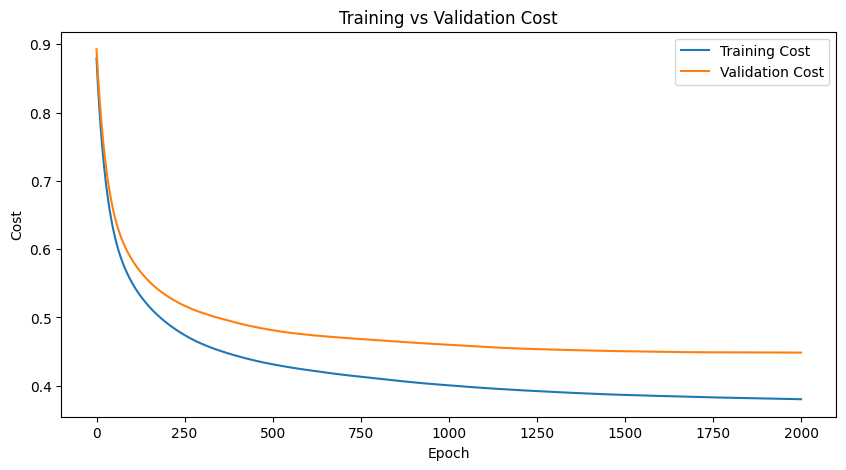

Best checkpoint saved at epoch 2000 with val_cost=0.4485


In [ ]:
final_parameters, train_costs, val_costs = model(
    X_train_mlp, y_train_mlp,
    X_val_mlp, y_val_mlp,
    layer_dims=best_layer_dims,
    learning_rate=best_params["learning_rate"],
    num_epochs=2000,
    lambd=best_params["lambda_reg"],
    checkpoint_file="final_mlp_optuna.pkl",
    print_every=100
)

# Final Evaluation on Train & Validation

In [ ]:
# Forward pass
AL_train, _ = forward_pass(X_train_mlp, final_parameters)
AL_val, _   = forward_pass(X_val_mlp, final_parameters)

# Metrics
train_metrics = compute_metrics(AL_train, y_train_mlp)
val_metrics   = compute_metrics(AL_val, y_val_mlp)

print("Final Train Metrics:", train_metrics)
print("Final Validation Metrics:", val_metrics)

Final Train Metrics: {'accuracy': 0.8291571753986323, 'precision': 0.8550368550368529, 'recall': 0.7927107061503398, 'f1': 0.8226950354604916, 'TP': 348, 'TN': 380, 'FP': 59, 'FN': 91}
Final Validation Metrics: {'accuracy': 0.8268156424580959, 'precision': 0.787878787878776, 'recall': 0.7536231884057862, 'f1': 0.7703703703698591, 'TP': 52, 'TN': 96, 'FP': 14, 'FN': 17}


# Saving the Final Trained Model

In [ ]:
with open("final_mlp_parameters.pkl", "wb") as f:
    pickle.dump(final_parameters, f)

print("Final model saved successfully.")

Final model saved successfully.


# Saving Metadata

In [ ]:
model_info = {
    "layer_dims": best_layer_dims,
    "learning_rate": best_params["learning_rate"],
    "lambda_reg": best_params["lambda_reg"],
    "train_metrics": train_metrics,
    "val_metrics": val_metrics
}

with open("final_mlp_metadata.pkl", "wb") as f:
    pickle.dump(model_info, f)

# Reloading the Model

In [ ]:
with open("final_mlp_parameters.pkl", "rb") as f:
    loaded_parameters = pickle.load(f)

print("Model reloaded successfully.")

Model reloaded successfully.


# Evaluating on Test Set

## Test Set Preparation

In [ ]:
# Keep PassengerId for later (submission / evaluation)
test_passenger_ids = test_df["PassengerId"].copy()

# Drop same columns as training
X_test = test_df.drop(columns=["Name", "Ticket"])

# Encode categorical features (same logic as training)
X_test["Sex"] = LabelEncoder().fit_transform(X_test["Sex"])
X_test["Embarked"] = LabelEncoder().fit_transform(X_test["Embarked"])

# Scale using the SAME scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame (for consistency & inspection)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Convert to MLP input shape (n_features, m)
X_test_mlp = X_test_scaled_df.to_numpy().T

# Final sanity check
print("X_test_scaled_df shape:", X_test_scaled_df.shape)
print("X_test_mlp shape:", X_test_mlp.shape)


X_test_scaled_df shape: (418, 8)
X_test_mlp shape: (8, 418)


In [ ]:
# Predict on test set
test_preds = predict(X_test_mlp, loaded_parameters).reshape(-1)  # (418,)
print("Predictions shape:", test_preds.shape)
print("First 10 predictions:", test_preds[:10])

Predictions shape: (418,)
First 10 predictions: [0 0 0 0 1 0 1 0 1 0]


# Evaluating on the full Dataset

In [ ]:
# Evaluate test predictions using full_df labels (matching by shared identity columns)

t, f = test_df.copy(), full_df.copy()
t.columns, f.columns = t.columns.str.lower(), f.columns.str.lower()

t["pred_survived"] = test_preds  # test_preds must already exist (shape 418,)

keys = [c for c in ["name","sex","age","sibsp","parch","ticket","fare","cabin","embarked","pclass"]
        if c in t.columns and c in f.columns]

for c in keys:
    if c in ["age","fare"]:
        t[c], f[c] = pd.to_numeric(t[c], errors="coerce"), pd.to_numeric(f[c], errors="coerce")
    else:
        t[c], f[c] = t[c].astype(str), f[c].astype(str)

m = t.merge(f[keys + ["survived"]], on=keys, how="left")
mask = m["survived"].notna()

print(f"Matched: {mask.sum()}/{len(m)}")

test_metrics = compute_metrics(
    m.loc[mask, "pred_survived"].astype(int).to_numpy().reshape(1, -1),
    m.loc[mask, "survived"].astype(int).to_numpy().reshape(1, -1)
)
print("Test Metrics:", test_metrics)

Matched: 314/418
Test Metrics: {'accuracy': 0.7547770700636918, 'precision': 0.6737588652482221, 'recall': 0.7539682539682481, 'f1': 0.7116104868908819, 'TP': 95, 'TN': 142, 'FP': 46, 'FN': 31}


# Save the Submission File

In [ ]:
submission = pd.DataFrame({
    "PassengerId": test_passenger_ids.values,
    "Survived": test_preds
})
submission.to_csv("submission.csv", index=False)

print("Saved: submission.csv")
submission.head()

Saved: submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


# Hyperopt
**Hyperopt** is another widely used library for hyperparameter optimization that leverages Bayesian optimization methods, including the **Tree-structured Parzen Estimator (TPE)**. It is designed to support complex search spaces, allowing real-valued, discrete, and conditional hyperparameters. Hyperopt enables efficient hyperparameter tuning by minimizing or maximizing a user-defined objective function.

A key advantage of Hyperopt is its support for parallel execution, which can significantly accelerate the optimization process. This is particularly beneficial when working with large datasets or computationally intensive models, as multiple hyperparameter configurations can be evaluated simultaneously.
.

***References:***
*   https://www.blog.trainindata.com/overcoming-class-imbalance-with-smote/
*   https://www.geeksforgeeks.org/machine-learning/feature-engineering-scaling-normalization-and-standardization/
*   https://docs.databricks.com/en/machine-learning/automl-hyperparam-tuning/optuna.html
*   https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/
*   https://www.analyticsvidhya.com/blog/2020/09/alternative-hyperparameter-optimization-technique-you-need-to-know-hyperopt/
*   https://numpy.org/doc/stable/reference/generated/numpy.sum.html
*   https://github.com/ResidentMario/


---

**By: Khawla Chrifi Alaoui**

---
